# IntelliSys: AI-Powered Retail Image Processing

Online retailers and catalogue management platforms face a **high-volume, labour-intensive bottleneck**: every product image uploaded to a platform must be correctly categorised before it can be listed, searched, or recommended. Doing this manually is slow, expensive, and inconsistent — a human labeller might tag a "pullover" as a "coat" depending on the image angle or their own interpretation.

IntelliSys is positioning this as an **AI-powered retail image processing module**, a service component it can offer to clients who operate:

- E-commerce platforms needing automated SKU tagging
- Warehouse or stock management systems requiring visual inventory classification
- Shopping apps that auto-categorise user-uploaded second-hand listings

This notebook develops a deep learning image classification pipeline using the **Fashion-MNIST** dataset as a proxy for real-world retail product images. We build and compare three models of increasing sophistication, analyse their errors, and interpret their decisions using Grad-CAM.

**Sections:**
1. Setup & Data Exploration
2. Preprocessing
3. Baseline Model
4. Improved Models (A: reference-level, B: advanced techniques)
5. Evaluation & Error Analysis
6. Interpretability (Grad-CAM)
7. Recommendations & Risks

---

## ⚙️ Environment Setup

### Required Packages

This notebook depends on the following libraries:

| Package | Purpose |
|---|---|
| `torch` | Model definition, training loop, loss, optimiser |
| `torchvision` | Fashion-MNIST dataset loading and transforms |
| `numpy` | Numerical operations |
| `matplotlib` | Plotting and visualisation |
| `seaborn` | Confusion matrix heatmaps |
| `pandas` | Results tables |
| `scikit-learn` | Classification report, F1 score, PCA |

---

### 🟡 Running on Google Colab

Colab comes with most packages pre-installed. Only `torchvision` may need confirming. Run the following cell **before all others**:

```python
# Colab setup
!pip install torch torchvision --quiet

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
```

**Enable GPU acceleration** (strongly recommended for Model B training):  
`Runtime` → `Change runtime type` → set Hardware accelerator to **GPU (T4)**

> **Note:** Fashion-MNIST will be automatically downloaded to `/root/.cache` on first run. No manual download is needed.

---

### 🔵 Running on Azure Machine Learning

The notebook was developed on **Azure ML** using the `Python 3.10 - AzureML` kernel. The default AzureML curated environment includes most dependencies, but verify your compute cluster has GPU support enabled.

**1. Confirm your kernel**  
In the notebook toolbar, ensure the kernel is set to:  
`Python 3.10 - AzureML` (or `python38-azureml` for older workspaces)

**2. Check and install any missing packages**  
Run this at the top of your session:

```python
# Azure ML setup check
import subprocess

packages = ["torch", "torchvision", "scikit-learn", "seaborn", "pandas"]
for pkg in packages:
    result = subprocess.run(["pip", "show", pkg], capture_output=True, text=True)
    status = "✅ installed" if result.returncode == 0 else "❌ missing"
    print(f"{pkg}: {status}")
```

If any package shows as missing, install it with:

```python
!pip install torch torchvision scikit-learn seaborn pandas --quiet
```

**3. GPU compute**  
Ensure your compute instance or cluster uses a GPU-enabled VM (e.g. `Standard_NC6` or `Standard_NC6s_v3`). Training Model B on CPU will be significantly slower.

**4. Dataset download**  
Fashion-MNIST is downloaded automatically via `torchvision.datasets.FashionMNIST`. Ensure your compute has outbound internet access, or pre-download the dataset and update the `root` path in Section 1.

---

### 💻 Running Locally

```bash
# Create and activate a virtual environment (recommended)
python -m venv intellisys-env
source intellisys-env/bin/activate        # macOS/Linux
intellisys-env\Scripts\activate           # Windows

# Install all dependencies
pip install torch torchvision numpy matplotlib seaborn pandas scikit-learn

# Launch the notebook
jupyter notebook final_notebook.ipynb
```

> **GPU (optional but recommended):** If you have an NVIDIA GPU, install the CUDA-compatible version of PyTorch from [pytorch.org](https://pytorch.org/get-started/locally/) for significantly faster training.

---

### ✅ Quick Sanity Check

Paste and run this cell after setup to confirm everything is working:

```python
import torch, torchvision, sklearn, matplotlib, seaborn, pandas, numpy

print(f"PyTorch      : {torch.__version__}")
print(f"Torchvision  : {torchvision.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print("All packages loaded successfully ✅")
```

### Results & Runtime
Model A was trained using 50 epochs & Model B was trained using 75 but for reproducibility and runtime they have been both set to 20 epochs.

---
## 1. Setup & Data Exploration

We load the Fashion-MNIST dataset via `torchvision`, establish train/validation/test splits, and explore the data to inform model design decisions.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.decomposition import PCA
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

In [3]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f'Number of classes: {NUM_CLASSES}')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i}: {name}')

Number of classes: 10
  0: T-shirt/top
  1: Trouser
  2: Pullover
  3: Dress
  4: Coat
  5: Sandal
  6: Shirt
  7: Sneaker
  8: Bag
  9: Ankle boot


In [4]:
raw_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=None)
raw_test = datasets.FashionMNIST(root='./data', train=False, download=True, transform=None)

print(f'Training set size: {len(raw_train)}')
print(f'Test set size:     {len(raw_test)}')

Training set size: 60000
Test set size:     10000


In [5]:
train_images = raw_train.data.numpy()
train_labels = raw_train.targets.numpy()
test_images  = raw_test.data.numpy()
test_labels  = raw_test.targets.numpy()

print('=== Image Properties ===')
print(f'Shape:       {train_images[0].shape}')
print(f'Dtype:       {train_images.dtype}')
print(f'Pixel range: [{train_images.min()}, {train_images.max()}]')
print(f'Mean pixel:  {train_images.mean():.2f}')
print(f'Std pixel:   {train_images.std():.2f}')

train_float = train_images.astype(np.float32) / 255.0
print(f'\n=== Normalised [0,1] Statistics ===')
print(f'Mean: {train_float.mean():.4f}')
print(f'Std:  {train_float.std():.4f}')
print(f'\nTotal training samples:   {len(train_images)}')
print(f'Total test samples:       {len(test_images)}')
print(f'Will split training into: 50,000 train + 10,000 validation')

=== Image Properties ===
Shape:       (28, 28)
Dtype:       uint8
Pixel range: [0, 255]
Mean pixel:  72.94
Std pixel:   90.02

=== Normalised [0,1] Statistics ===
Mean: 0.2860
Std:  0.3530

Total training samples:   60000
Total test samples:       10000
Will split training into: 50,000 train + 10,000 validation


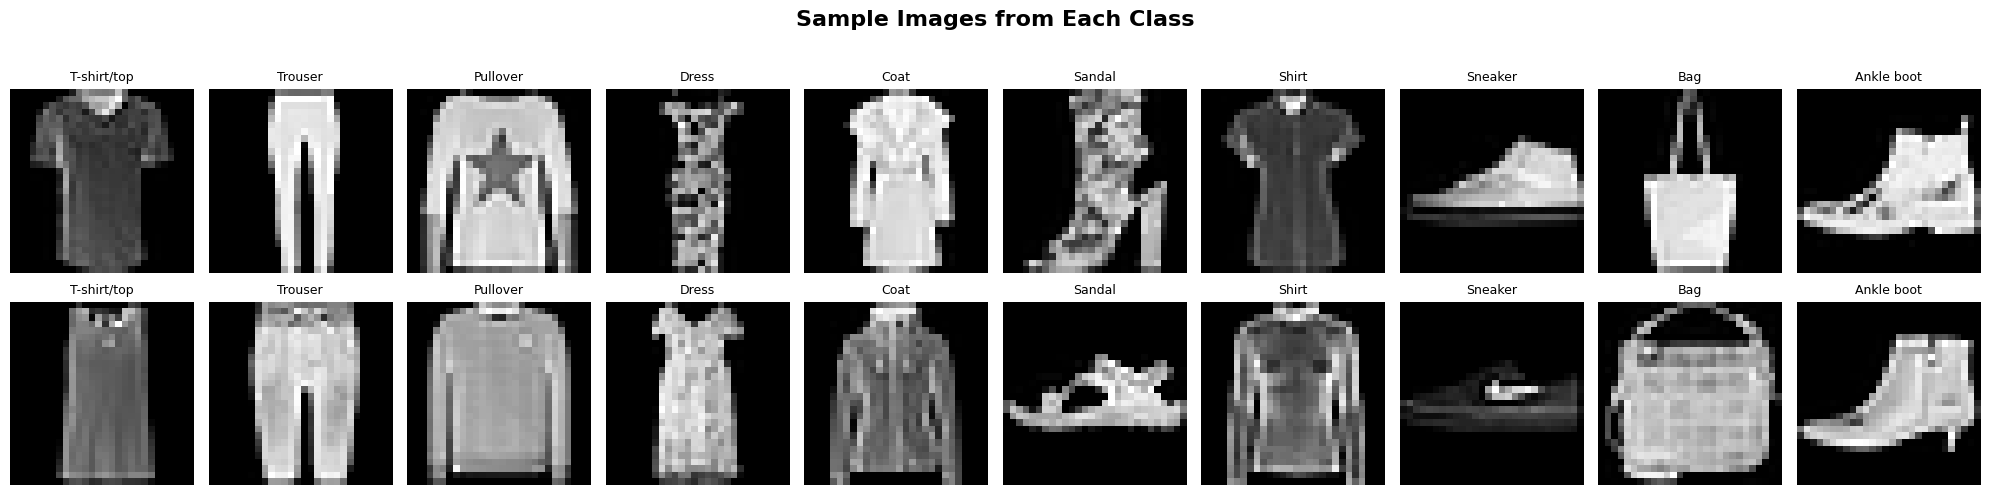

In [6]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(20, 5))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.02)
for cls_idx in range(NUM_CLASSES):
    class_indices = np.where(train_labels == cls_idx)[0]
    samples = np.random.choice(class_indices, size=2, replace=False)
    for row, sample_idx in enumerate(samples):
        ax = axes[row, cls_idx]
        ax.imshow(train_images[sample_idx], cmap='gray')
        ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.show()

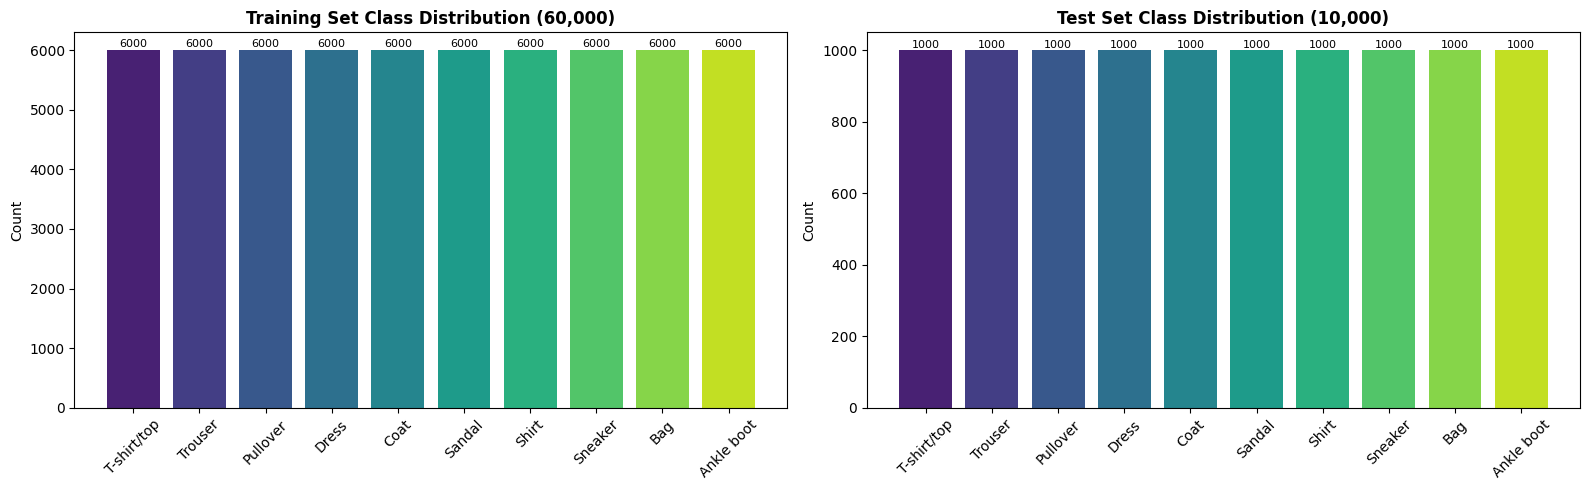

Classes are perfectly balanced: 6,000 per class (train), 1,000 per class (test).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
unique_train, counts_train = np.unique(train_labels, return_counts=True)
axes[0].bar([CLASS_NAMES[i] for i in unique_train], counts_train,
            color=sns.color_palette('viridis', NUM_CLASSES))
axes[0].set_title('Training Set Class Distribution (60,000)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, count in enumerate(counts_train):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=8)

unique_test, counts_test = np.unique(test_labels, return_counts=True)
axes[1].bar([CLASS_NAMES[i] for i in unique_test], counts_test,
            color=sns.color_palette('viridis', NUM_CLASSES))
axes[1].set_title('Test Set Class Distribution (10,000)', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, count in enumerate(counts_test):
    axes[1].text(i, count + 5, str(count), ha='center', fontsize=8)
plt.tight_layout()
plt.show()
print('Classes are perfectly balanced: 6,000 per class (train), 1,000 per class (test).')

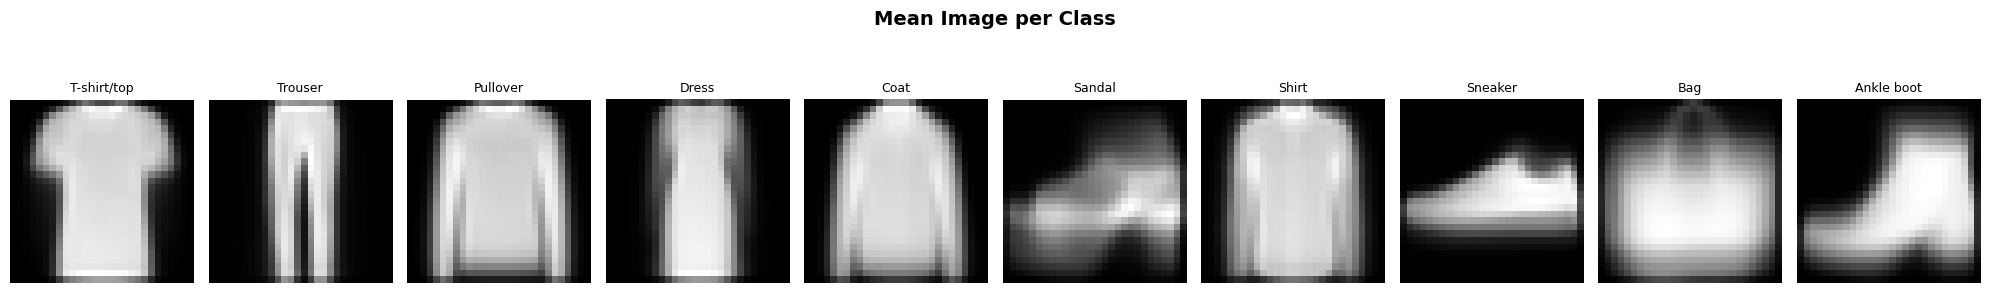

In [8]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 3))
fig.suptitle('Mean Image per Class', fontsize=14, fontweight='bold', y=1.05)
for cls_idx in range(NUM_CLASSES):
    class_mask = train_labels == cls_idx
    mean_img = train_images[class_mask].mean(axis=0)
    axes[cls_idx].imshow(mean_img, cmap='gray')
    axes[cls_idx].set_title(CLASS_NAMES[cls_idx], fontsize=9)
    axes[cls_idx].axis('off')
plt.tight_layout()
plt.show()

### Retail Label Mapping

Each Fashion-MNIST class corresponds to a real-world retail catalogue category. This mapping contextualises the classification task as a product categorisation problem.

In [9]:
retail_catalogue_mapping = {
    0: 'Tops / T-shirts',
    1: 'Bottoms / Trousers',
    2: 'Knitwear / Pullovers',
    3: 'Dresses',
    4: 'Outerwear / Coats',
    5: 'Footwear / Sandals',
    6: 'Shirts / Casual Tops',
    7: 'Footwear / Sneakers',
    8: 'Accessories / Bags',
    9: 'Footwear / Boots'
}

mapping_df = pd.DataFrame({
    'Label ID': list(retail_catalogue_mapping.keys()),
    'Fashion-MNIST Label': CLASS_NAMES,
    'Retail Catalogue Equivalent': list(retail_catalogue_mapping.values())
})

mapping_df

,Label ID,Fashion-MNIST Label,Retail Catalogue Equivalent
0,0,T-shirt/top,Tops / T-shirts
1,1,Trouser,Bottoms / Trousers
2,2,Pullover,Knitwear / Pullovers
3,3,Dress,Dresses
4,4,Coat,Outerwear / Coats
5,5,Sandal,Footwear / Sandals
6,6,Shirt,Shirts / Casual Tops
7,7,Sneaker,Footwear / Sneakers
8,8,Bag,Accessories / Bags
9,9,Ankle boot,Footwear / Boots


### Pixel Intensity Distribution

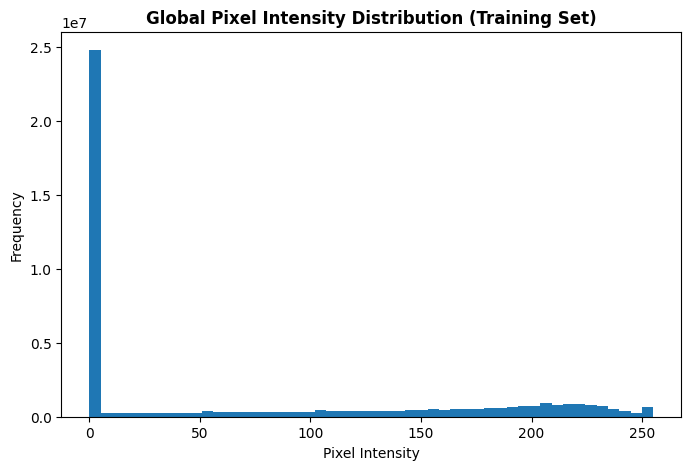

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(train_images.flatten(), bins=50)
plt.title('Global Pixel Intensity Distribution (Training Set)', fontweight='bold')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

The pixel intensity distribution is heavily skewed towards low values (near 0), which is expected because Fashion-MNIST images have large dark background regions. The informative features such as edges, textures, and shapes, are concentrated in the brighter foreground pixels.

### Low-Dimensional Structure (PCA)

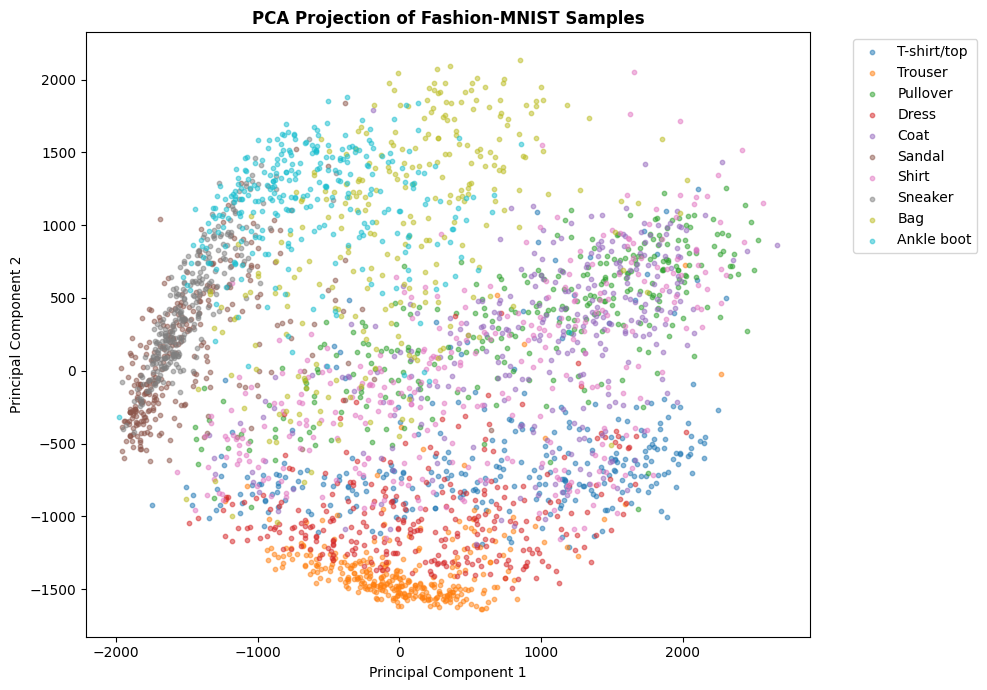

In [11]:
# Sample a subset for PCA visualisation
sample_size = 3000
np.random.seed(SEED)
sample_indices = np.random.choice(len(train_images), sample_size, replace=False)

X_sample = train_images[sample_indices]
y_sample = train_labels[sample_indices]

# Flatten images: (N, 28, 28) -> (N, 784)
X_sample_flat = X_sample.reshape(sample_size, -1)

# PCA projection to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample_flat)

plt.figure(figsize=(10, 7))
for class_id in range(NUM_CLASSES):
    plt.scatter(
        X_pca[y_sample == class_id, 0],
        X_pca[y_sample == class_id, 1],
        s=10, alpha=0.5,
        label=CLASS_NAMES[class_id]
    )
plt.title('PCA Projection of Fashion-MNIST Samples', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The PCA plot shows that some categories (e.g., Trouser, Bag) form distinct clusters, while visually related clothing items (T-shirt/top, Shirt, Pullover, Coat) overlap substantially in the original pixel space. This confirms that Fashion-MNIST is not a trivial classification problem and supports the use of CNNs to learn more expressive spatial features than linear methods can capture.

### Visually Confusable Categories

In retail settings, classification difficulty often arises from visual similarity between related products rather than class imbalance. We compare example images from several categories that are likely to be confused.

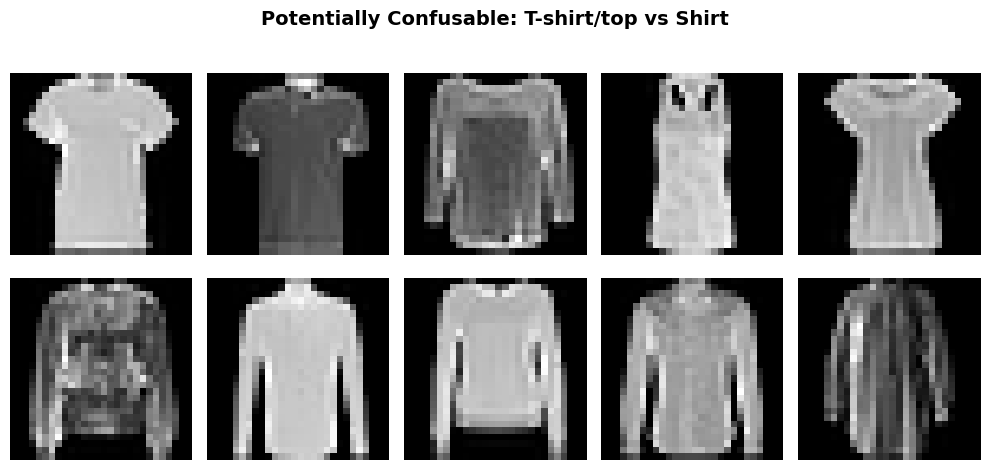

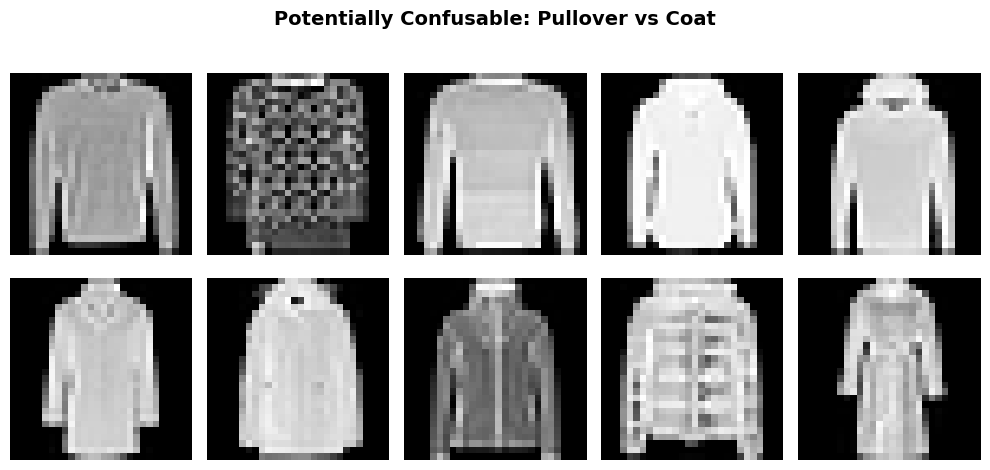

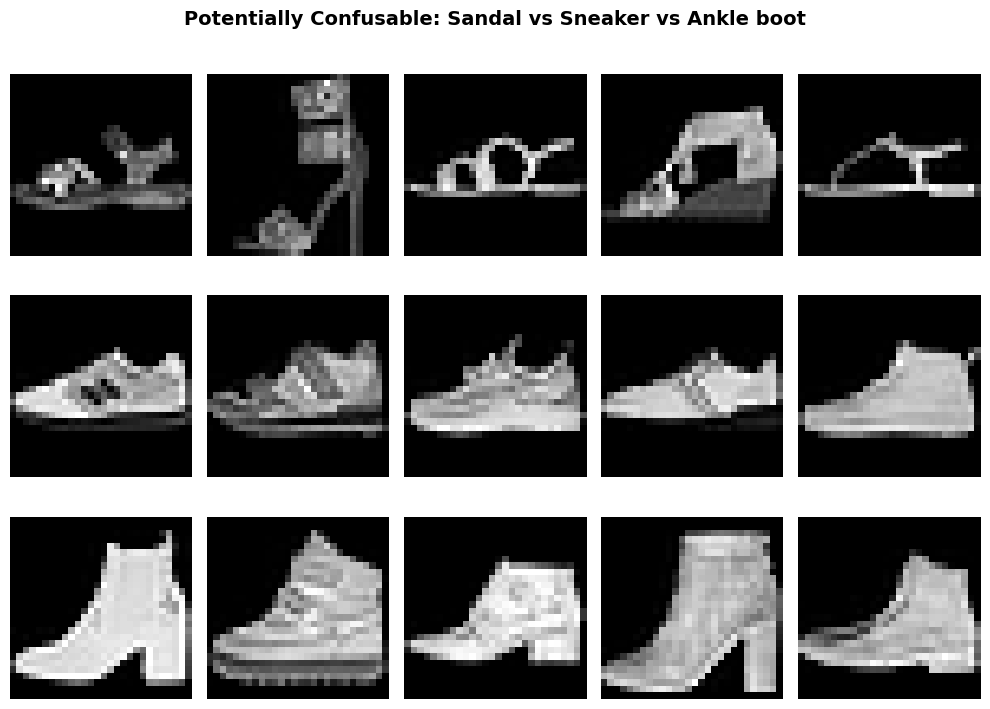

In [12]:
def plot_class_examples(target_classes, n_examples=5, title='Category Comparison'):
    fig, axes = plt.subplots(len(target_classes), n_examples,
                             figsize=(2 * n_examples, 2.5 * len(target_classes)))
    if len(target_classes) == 1:
        axes = np.array([axes])
    for row_idx, class_id in enumerate(target_classes):
        class_indices = np.where(train_labels == class_id)[0]
        selected = np.random.choice(class_indices, n_examples, replace=False)
        for col_idx, idx in enumerate(selected):
            axes[row_idx, col_idx].imshow(train_images[idx], cmap='gray')
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(CLASS_NAMES[class_id], fontsize=10)
            axes[row_idx, col_idx].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# T-shirt/top vs Shirt
plot_class_examples([0, 6], n_examples=5,
                    title='Potentially Confusable: T-shirt/top vs Shirt')

# Pullover vs Coat
plot_class_examples([2, 4], n_examples=5,
                    title='Potentially Confusable: Pullover vs Coat')

# Sandal vs Sneaker vs Ankle boot
plot_class_examples([5, 7, 9], n_examples=5,
                    title='Potentially Confusable: Sandal vs Sneaker vs Ankle boot')

T-shirt/top and Shirt differ only in subtle details (sleeve length, collar), while Pullover and Coat share similar upper-body silhouettes. Among footwear, Sandal is distinctive but Sneaker and Ankle boot can overlap in structure. These comparisons suggest that prediction errors are most likely between visually adjacent categories, not from class imbalance.

### Observations Affecting Model Design

1. **Image properties**: All images are 28x28 greyscale (single channel), with pixel values in [0, 255]. This is low resolution — fine-grained details (collars, buttons, stitching) are largely lost.

2. **Class balance**: The dataset is perfectly balanced (6,000 samples per class in training, 1,000 per class in test). We do not need class weighting or oversampling strategies.

3. **Visual similarity between classes**: The mean images reveal that several upper-body garment classes share very similar silhouettes:
   - **T-shirt/top, Pullover, Coat, Shirt** all show a roughly T-shaped outline with arms extended. At 28x28, their distinguishing features (neckline, sleeve length, buttons) are barely visible.
   - **Sandal, Sneaker, Ankle boot** form a footwear cluster that may confuse the model.
   - **Bag** and **Trouser** have very distinctive shapes and should be easy to classify.

4. **Implications for architecture**: Since the images are small (28x28), we should avoid very deep architectures that would reduce spatial dimensions too aggressively. Two to three convolutional blocks with max pooling should be sufficient. The visual similarity between classes suggests we need enough filters to learn subtle discriminating features.


---
## 2. Preprocessing

### Normalisation Strategy

We apply two normalisation steps:

1. **`transforms.ToTensor()`** converts PIL images to float32 tensors and scales pixel values from [0, 255] to [0, 1].
2. **`transforms.Normalize(mean, std)`** zero-centres and scales to approximately unit variance using the Fashion-MNIST training set statistics.

**Why this approach?** Zero-centring and unit-variance scaling ensures that all input features (pixels) have comparable magnitudes, which:
- Prevents any single pixel position from dominating the gradient updates
- Helps gradient-based optimisers (SGD, Adam) converge faster and more reliably
- Is more principled than raw [0, 1] scaling because it accounts for the actual distribution of the data

We compute the dataset-specific mean and standard deviation from the training set (not the test set, to avoid data leakage).

### Data Augmentation Strategy

For the advanced model (Model B), we apply augmentation to the training set:

| Augmentation | Justification |
|---|---|
| **Random horizontal flip** | Clothing items are left-right symmetric. A mirrored shirt is still a shirt. This effectively doubles the training set. |
| **Random rotation (±10°)** | Real product photos may have slight angle variations from different photographers or user uploads. |
| **Random affine translation (±10%)** | Products may not be perfectly centred in user-uploaded images. |

**Not applied:**
- Vertical flip — clothing has a clear up/down orientation
- Colour jitter — images are greyscale
- Random crop — at 28x28, cropping would discard too much information


In [13]:
FMNIST_MEAN = (train_float.mean(),)
FMNIST_STD  = (train_float.std(),)
print(f'Normalisation constants: mean={FMNIST_MEAN[0]:.4f}, std={FMNIST_STD[0]:.4f}')

Normalisation constants: mean=0.2860, std=0.3530


In [14]:
# Standard transform (for baseline, Model A, and all validation/test sets)
transform_standard = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD)
])

# Augmented transform (for Model B training only)
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD)
])

print('Standard transform:', transform_standard)
print()
print('Augmented transform:', transform_augmented)

Standard transform: Compose(
    ToTensor()
    Normalize(mean=(0.2860402,), std=(0.3530239,))
)

Augmented transform: Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
    ToTensor()
    Normalize(mean=(0.2860402,), std=(0.3530239,))
)


In [15]:
# Load datasets with transforms
full_train_standard = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_standard)
full_train_augmented = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_augmented)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_standard)

# Train/Validation split (50,000 / 10,000)
train_size = 50000
val_size   = 10000
generator = torch.Generator().manual_seed(SEED)
all_indices = list(range(len(full_train_standard)))
train_indices, val_indices = random_split(all_indices, [train_size, val_size], generator=generator)
train_indices = list(train_indices)
val_indices   = list(val_indices)

train_subset_standard = Subset(full_train_standard, train_indices)
val_subset             = Subset(full_train_standard, val_indices)
train_subset_augmented = Subset(full_train_augmented, train_indices)

print(f'Training set:    {len(train_subset_standard)} samples')
print(f'Validation set:  {len(val_subset)} samples')
print(f'Test set:        {len(test_dataset)} samples')

Training set:    50000 samples
Validation set:  10000 samples
Test set:        10000 samples


In [16]:
BATCH_SIZE = 64

train_loader_standard = DataLoader(train_subset_standard, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE * 4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE * 4, shuffle=False)
train_loader_augmented = DataLoader(train_subset_augmented, batch_size=BATCH_SIZE, shuffle=True)

x_batch, y_batch = next(iter(train_loader_standard))
print(f'Batch shape: {x_batch.shape}')
print(f'Label shape: {y_batch.shape}')
print(f'Pixel range after normalisation: [{x_batch.min():.2f}, {x_batch.max():.2f}]')

Batch shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])
Pixel range after normalisation: [-0.81, 2.02]


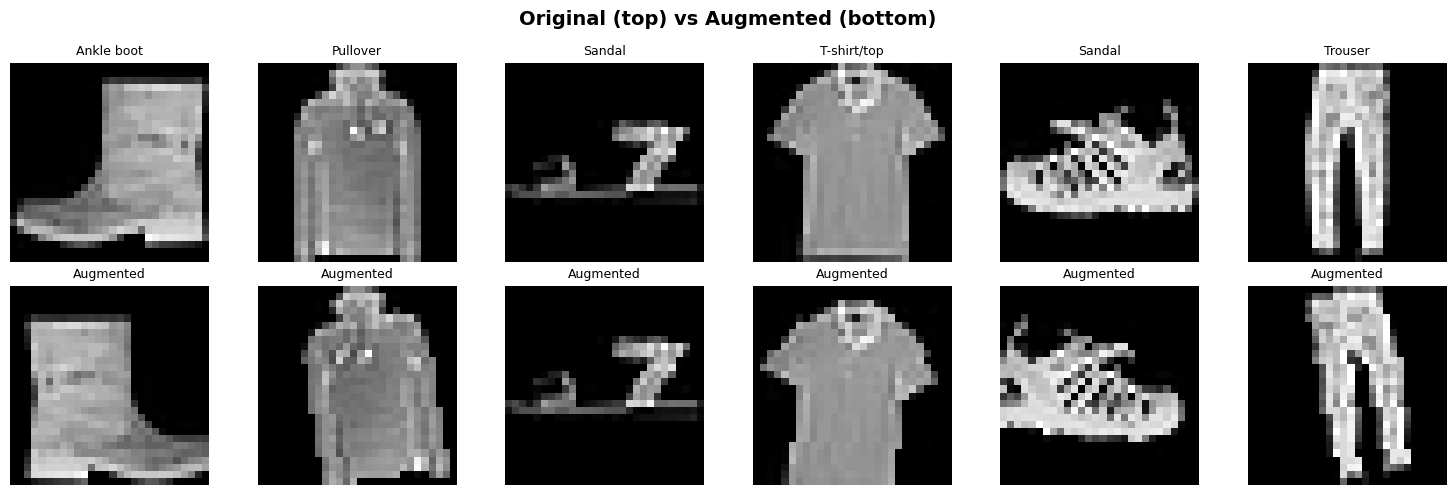

In [17]:
# Visualise augmented vs original
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Original (top) vs Augmented (bottom)', fontsize=14, fontweight='bold')
for i in range(6):
    idx = train_indices[i]
    img_orig, label = full_train_standard[idx]
    axes[0, i].imshow(img_orig.squeeze(), cmap='gray')
    axes[0, i].set_title(CLASS_NAMES[label], fontsize=9)
    axes[0, i].axis('off')
    img_aug, _ = full_train_augmented[idx]
    axes[1, i].imshow(img_aug.squeeze(), cmap='gray')
    axes[1, i].set_title('Augmented', fontsize=9)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

---
## 3. Baseline Model

Our baseline directly adapts the CNN architecture from the reference material (`1_Introduction_to_CNNs.ipynb`), which was designed for MNIST digit classification. Since Fashion-MNIST shares the same format (1x28x28, 10 classes), the architecture transfers directly.

**Architecture:**
- `Conv2d(1->10, 5x5)` -> MaxPool(2) -> ReLU
- `Conv2d(10->20, 5x5)` -> MaxPool(2) -> ReLU
- Flatten -> `Linear(320->50)` -> ReLU -> `Linear(50->10)`

**Training configuration** (matching reference):
- Optimizer: SGD (no momentum, matching the reference)
- Learning rate: 0.01
- Loss: Cross-entropy
- Batch size: 64
- Epochs: 10 (increased from reference's 3, since Fashion-MNIST is harder than MNIST)

In [18]:
class BaselineCNN(nn.Module):
    """CNN adapted from reference material (1_Introduction_to_CNNs.ipynb)."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.fc1   = nn.Linear(320, 50)
        self.fc2   = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))  # 1x28x28 -> 10x12x12
        x = F.relu(F.max_pool2d(self.conv2(x), 2))  # 10x12x12 -> 20x4x4
        x = x.view(-1, 320)                          # Flatten: 20*4*4 = 320
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # raw logits (F.cross_entropy applies softmax internally)
        return x

baseline_model = BaselineCNN()
print(baseline_model)
print(f'\nTotal parameters: {sum(p.numel() for p in baseline_model.parameters()):,}')

BaselineCNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

Total parameters: 21,840


In [19]:
def train_one_epoch(model, loader, optimizer, loss_fn, dev):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x_b, y_b in loader:
        x_b, y_b = x_b.to(dev), y_b.to(dev)
        preds = model(x_b)
        loss = loss_fn(preds, y_b)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item() * x_b.size(0)
        correct += (preds.argmax(dim=1) == y_b).sum().item()
        total += x_b.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, loss_fn, dev):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(dev), y_b.to(dev)
            preds = model(x_b)
            loss = loss_fn(preds, y_b)
            total_loss += loss.item() * x_b.size(0)
            pred_labels = preds.argmax(dim=1)
            correct += (pred_labels == y_b).sum().item()
            total += x_b.size(0)
            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(y_b.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, train_ldr, val_ldr, optimizer, loss_fn, dev,
                num_epochs, scheduler=None, model_name='Model'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    model.to(dev)
    start_time = time.time()
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_ldr, optimizer, loss_fn, dev)
        val_loss, val_acc, _, _ = evaluate(model, val_ldr, loss_fn, dev)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        print(f'  Epoch {epoch:2d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')
    elapsed = time.time() - start_time
    print(f'\n  {model_name} training complete in {elapsed:.1f}s')
    history['training_time'] = elapsed
    return history

In [20]:
def plot_training_curves(history, title='Training Curves'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    ax1.plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=4)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy', markersize=4)
    ax2.plot(epochs, history['val_acc'], 'r-o', label='Val Accuracy', markersize=4)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def full_evaluation(model, loader, loss_fn, dev, model_name='Model'):
    test_loss, test_acc, preds, labels = evaluate(model, loader, loss_fn, dev)
    print(f'\n=== {model_name} — Test Set Results ===')
    print(f'Test Loss:     {test_loss:.4f}')
    print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
    print()
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()
    return test_loss, test_acc, preds, labels


def visualise_predictions(test_ds, preds, labels, title='Predictions', n=12):
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    indices = np.random.choice(len(labels), size=n, replace=False)
    for i, idx in enumerate(indices):
        ax = axes[i // 4, i % 4]
        img, true_label = test_ds[idx]
        pred_label = preds[idx]
        ax.imshow(img.squeeze(), cmap='gray')
        colour = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}',
                     color=colour, fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

In [21]:
loss_fn = F.cross_entropy

baseline_model = BaselineCNN().to(device)
baseline_optimizer = optim.SGD(baseline_model.parameters(), lr=0.01)
baseline_history = train_model(
    baseline_model, train_loader_standard, val_loader,
    baseline_optimizer, loss_fn, device, num_epochs=10, model_name='Baseline CNN'
)

  Epoch  1/10 | Train Loss: 1.1220  Acc: 0.6157 | Val Loss: 0.8501  Acc: 0.6473
  Epoch  2/10 | Train Loss: 0.6333  Acc: 0.7608 | Val Loss: 0.5938  Acc: 0.7722
  Epoch  3/10 | Train Loss: 0.5307  Acc: 0.8025 | Val Loss: 0.5442  Acc: 0.8006
  Epoch  4/10 | Train Loss: 0.4773  Acc: 0.8246 | Val Loss: 0.4755  Acc: 0.8307
  Epoch  5/10 | Train Loss: 0.4383  Acc: 0.8402 | Val Loss: 0.4545  Acc: 0.8378
  Epoch  6/10 | Train Loss: 0.4094  Acc: 0.8521 | Val Loss: 0.4777  Acc: 0.8218
  Epoch  7/10 | Train Loss: 0.3857  Acc: 0.8625 | Val Loss: 0.4765  Acc: 0.8351
  Epoch  8/10 | Train Loss: 0.3705  Acc: 0.8664 | Val Loss: 0.4086  Acc: 0.8544
  Epoch  9/10 | Train Loss: 0.3543  Acc: 0.8716 | Val Loss: 0.3804  Acc: 0.8634
  Epoch 10/10 | Train Loss: 0.3426  Acc: 0.8767 | Val Loss: 0.3794  Acc: 0.8655

  Baseline CNN training complete in 108.0s


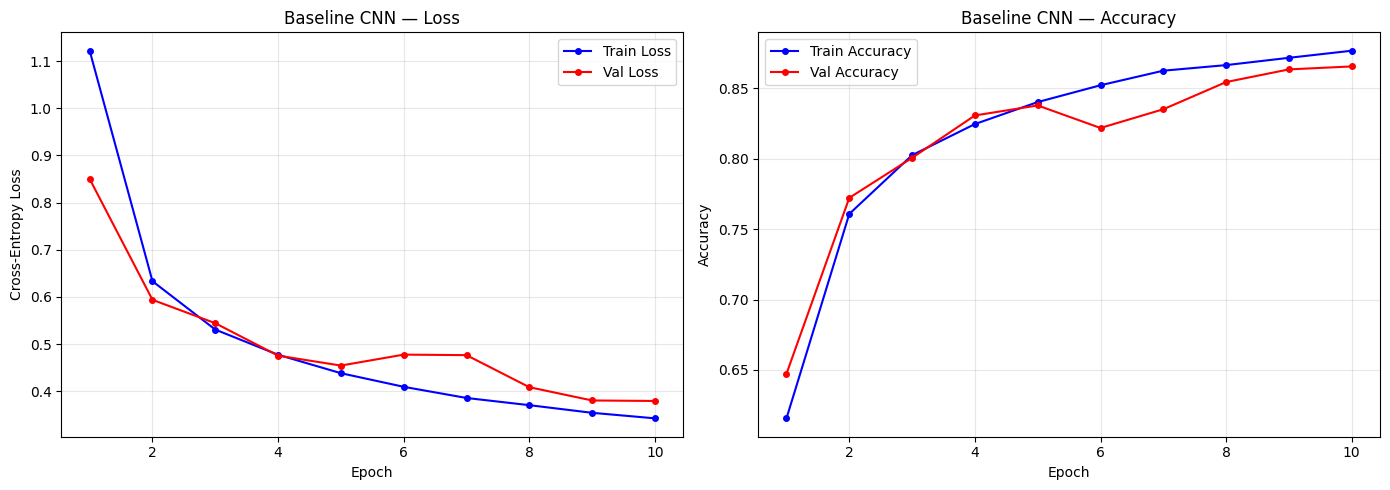

In [22]:
plot_training_curves(baseline_history, 'Baseline CNN')


=== Baseline CNN — Test Set Results ===
Test Loss:     0.3884
Test Accuracy: 0.8612 (86.1%)

              precision    recall  f1-score   support

 T-shirt/top     0.8567    0.7650    0.8082      1000
     Trouser     0.9908    0.9640    0.9772      1000
    Pullover     0.8623    0.7140    0.7812      1000
       Dress     0.8355    0.9090    0.8707      1000
        Coat     0.7864    0.7510    0.7683      1000
      Sandal     0.9068    0.9830    0.9434      1000
       Shirt     0.5823    0.7430    0.6529      1000
     Sneaker     0.9360    0.9060    0.9207      1000
         Bag     0.9663    0.9460    0.9560      1000
  Ankle boot     0.9738    0.9310    0.9519      1000

    accuracy                         0.8612     10000
   macro avg     0.8697    0.8612    0.8631     10000
weighted avg     0.8697    0.8612    0.8631     10000



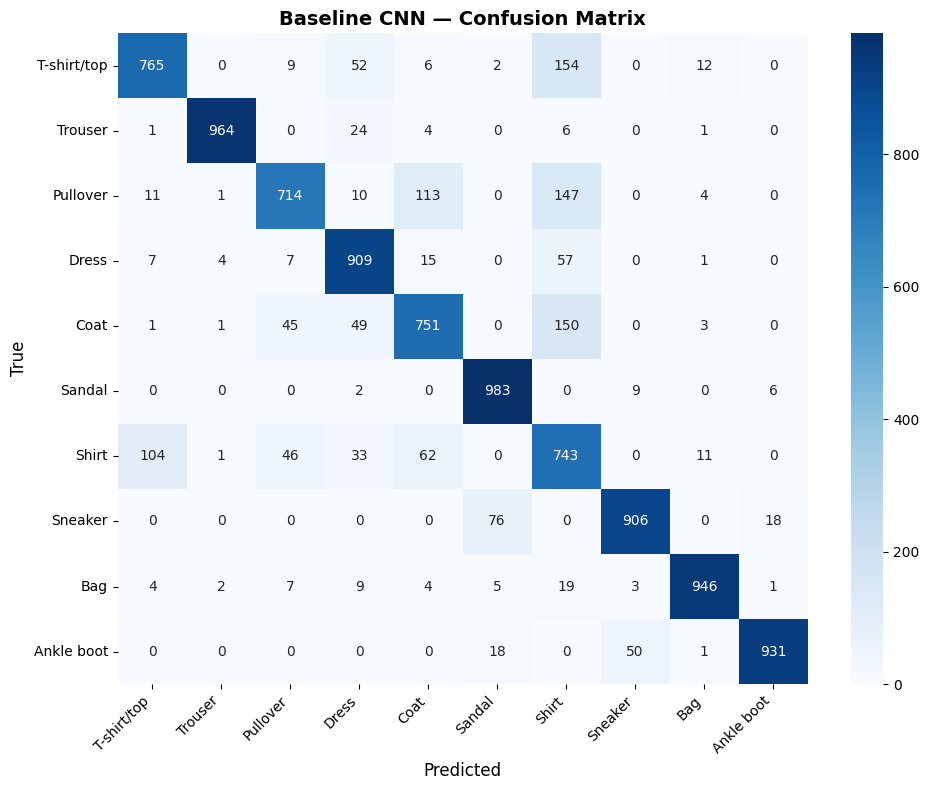

In [23]:
baseline_test_loss, baseline_test_acc, baseline_preds, baseline_labels = full_evaluation(
    baseline_model, test_loader, loss_fn, device, 'Baseline CNN'
)

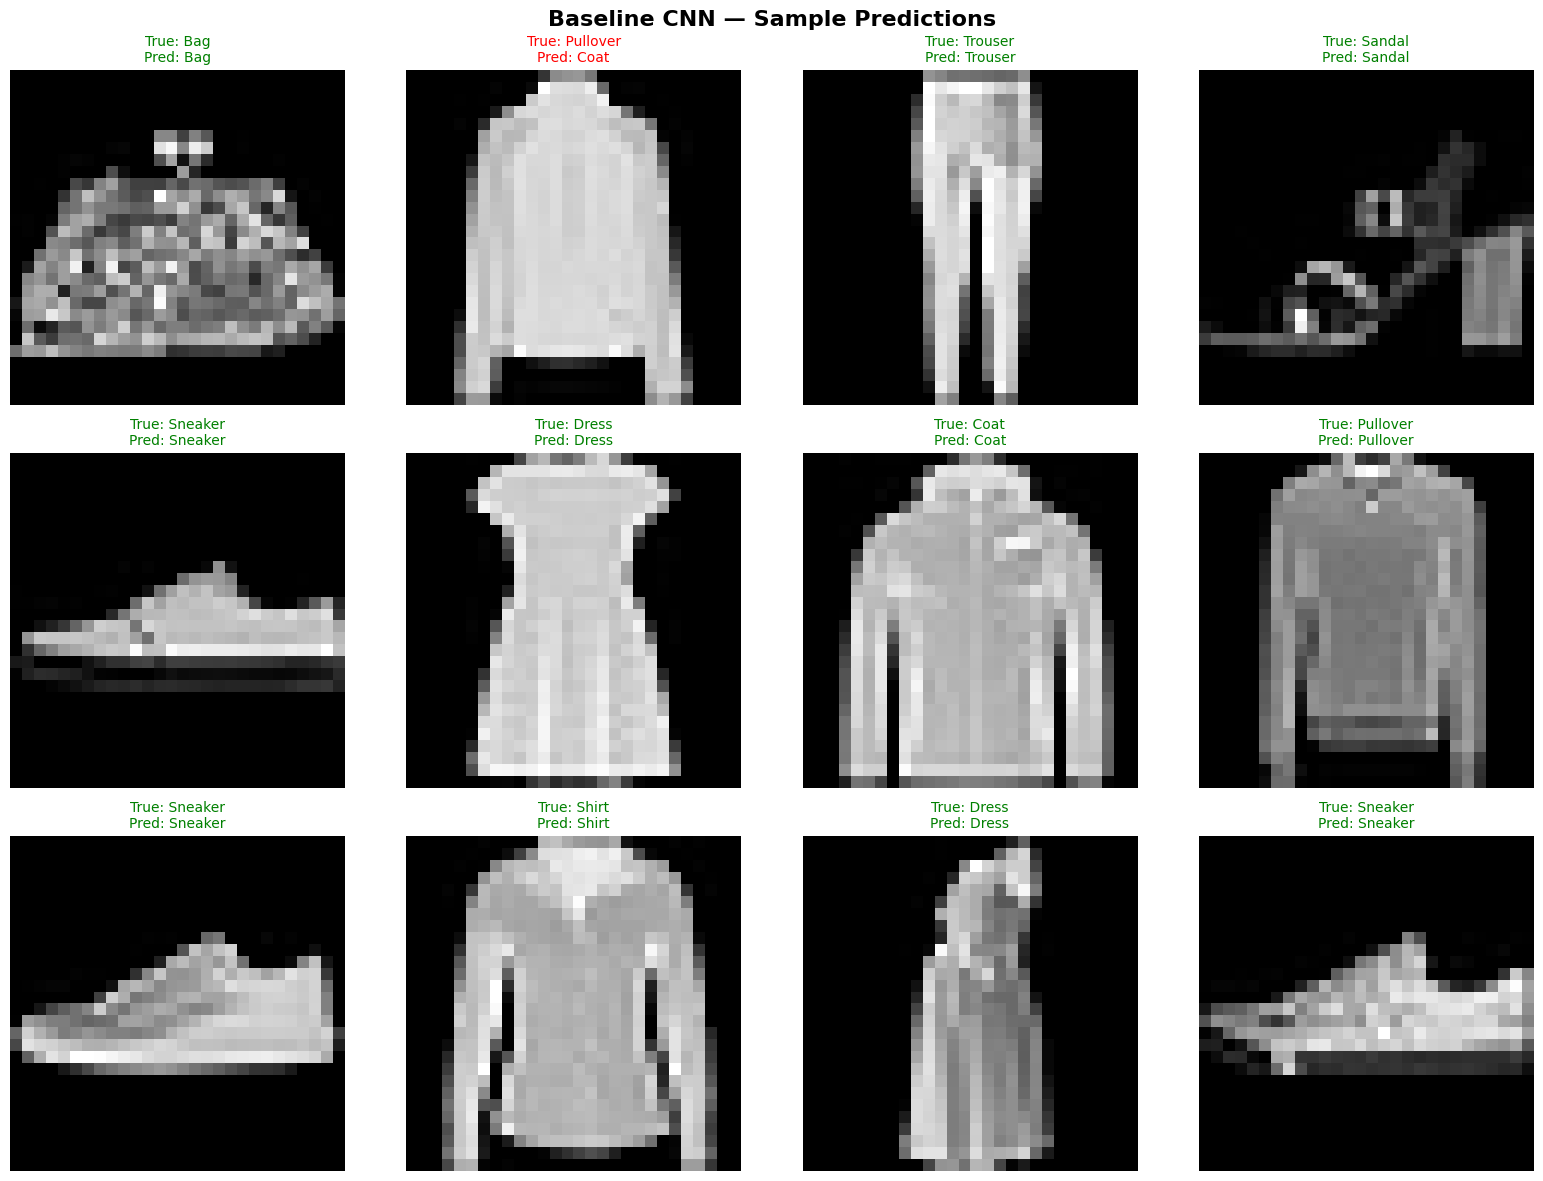

In [24]:
visualise_predictions(test_dataset, baseline_preds, baseline_labels,
                      'Baseline CNN — Sample Predictions')

### Baseline Results Summary

The baseline CNN, adapted directly from the reference material, achieves a reasonable starting accuracy on Fashion-MNIST. However, several weaknesses are visible:

1. **Limited capacity**: Only 10 and 20 filters in the two conv layers, and a tiny 50-unit FC layer — insufficient to capture the variety in 10 clothing classes.
2. **No regularisation**: The model may overfit (training accuracy significantly higher than validation accuracy).
3. **Plain SGD without momentum**: Slow convergence, particularly in the later epochs where the loss reduction plateaus.
4. **No padding**: The 5x5 kernels without padding shrink spatial dimensions aggressively.

These observations motivate the improvements in the next section.

---
## 4. Improved Models

### 4a. Improved Model A — Reference-Level Techniques

This model improves upon the baseline using **only techniques present in the reference notebooks** (convolution, max pooling, ReLU, fully connected layers, SGD with momentum). No techniques beyond what was taught are introduced.

| Baseline Weakness | Improvement | Justification |
|---|---|---|
| Only 2 conv layers with 10/20 filters | 3 conv layers with 32/64/128 filters | More convolutional filters increase the model's capacity to learn diverse features (edges, textures, shapes). The reference material shows that deeper networks with more feature maps extract richer representations. |
| 5x5 kernels with no padding | 3x3 kernels with `padding=1` | 3x3 is the standard minimum kernel size used in modern CNNs (VGGNet). Padding preserves spatial dimensions before pooling, retaining more spatial information. |
| 50-unit FC layer | 256-unit FC layer | The baseline's 50 units create an information bottleneck. 256 units provide sufficient capacity for the 10-class decision without being excessive. |
| Plain SGD (no momentum) | SGD with momentum=0.9 | Momentum accumulates gradient history to accelerate convergence in consistent directions and dampen oscillations. This is a standard SGD extension covered conceptually in the backpropagation reference. |
| 10 epochs | 50 epochs | Allows the larger model more time to converge, especially since Fashion-MNIST is harder than the MNIST used in the reference. |


In [25]:
class ImprovedCNN_A(nn.Module):
    """3 conv blocks (32->64->128), 3x3 kernels with padding, 256-unit FC."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))   # 28->14
        x = F.relu(F.max_pool2d(self.conv2(x), 2))   # 14->7
        x = F.relu(F.max_pool2d(self.conv3(x), 2))   # 7->3
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_a = ImprovedCNN_A()
print(model_a)
print(f'\nTotal parameters: {sum(p.numel() for p in model_a.parameters()):,}')

ImprovedCNN_A(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 390,410


In [ ]:
model_a = ImprovedCNN_A().to(device)
optimizer_a = optim.SGD(model_a.parameters(), lr=0.01, momentum=0.9)
history_a = train_model(
    model_a, train_loader_standard, val_loader,
    optimizer_a, loss_fn, device, num_epochs=20, model_name='Improved CNN A'
)

  Epoch  1/50 | Train Loss: 0.6471  Acc: 0.7646 | Val Loss: 0.3978  Acc: 0.8532
  Epoch  2/50 | Train Loss: 0.3439  Acc: 0.8735 | Val Loss: 0.3109  Acc: 0.8863
  Epoch  3/50 | Train Loss: 0.2904  Acc: 0.8922 | Val Loss: 0.2972  Acc: 0.8884
  Epoch  4/50 | Train Loss: 0.2574  Acc: 0.9048 | Val Loss: 0.2709  Acc: 0.9013
  Epoch  5/50 | Train Loss: 0.2321  Acc: 0.9139 | Val Loss: 0.2567  Acc: 0.9026
  Epoch  6/50 | Train Loss: 0.2116  Acc: 0.9204 | Val Loss: 0.2455  Acc: 0.9119
  Epoch  7/50 | Train Loss: 0.1990  Acc: 0.9253 | Val Loss: 0.2533  Acc: 0.9059
  Epoch  8/50 | Train Loss: 0.1818  Acc: 0.9315 | Val Loss: 0.2286  Acc: 0.9133
  Epoch  9/50 | Train Loss: 0.1659  Acc: 0.9382 | Val Loss: 0.2260  Acc: 0.9182
  Epoch 10/50 | Train Loss: 0.1508  Acc: 0.9430 | Val Loss: 0.2271  Acc: 0.9163
  Epoch 11/50 | Train Loss: 0.1398  Acc: 0.9468 | Val Loss: 0.2243  Acc: 0.9205
  Epoch 12/50 | Train Loss: 0.1278  Acc: 0.9521 | Val Loss: 0.2211  Acc: 0.9209
  Epoch 13/50 | Train Loss: 0.1168  Acc:

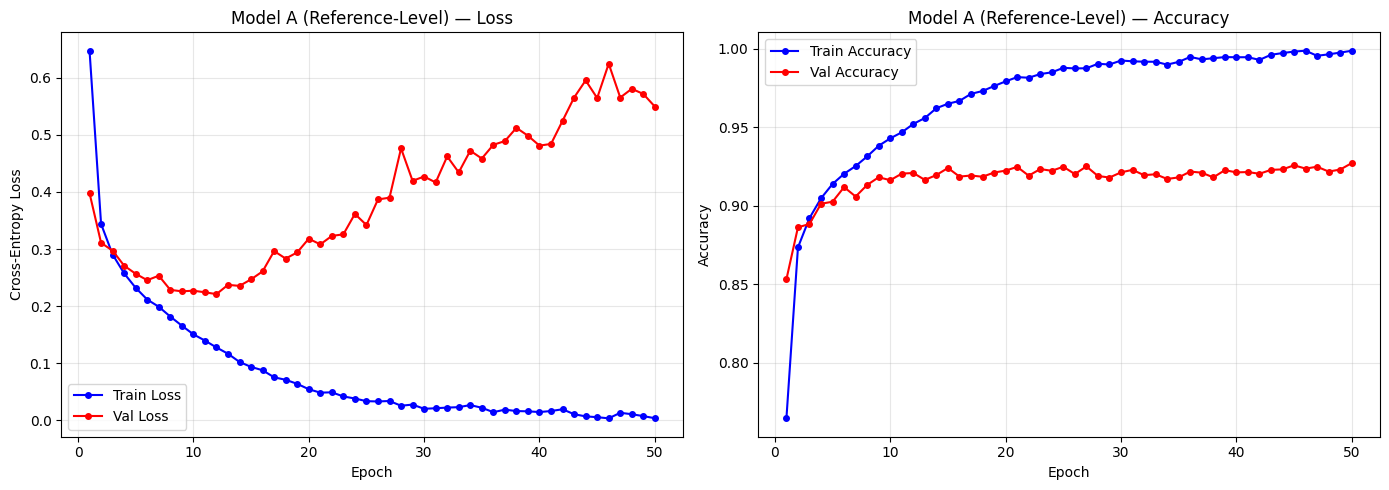

In [30]:
plot_training_curves(history_a, 'Model A (Reference-Level)')


=== Improved Model A — Test Set Results ===
Test Loss:     0.6585
Test Accuracy: 0.9193 (91.9%)

              precision    recall  f1-score   support

 T-shirt/top     0.8715    0.8610    0.8662      1000
     Trouser     0.9870    0.9850    0.9860      1000
    Pullover     0.8755    0.8860    0.8807      1000
       Dress     0.9117    0.9090    0.9104      1000
        Coat     0.8567    0.8970    0.8764      1000
      Sandal     0.9791    0.9860    0.9826      1000
       Shirt     0.7913    0.7470    0.7685      1000
     Sneaker     0.9576    0.9710    0.9643      1000
         Bag     0.9792    0.9880    0.9836      1000
  Ankle boot     0.9787    0.9630    0.9708      1000

    accuracy                         0.9193     10000
   macro avg     0.9188    0.9193    0.9189     10000
weighted avg     0.9188    0.9193    0.9189     10000



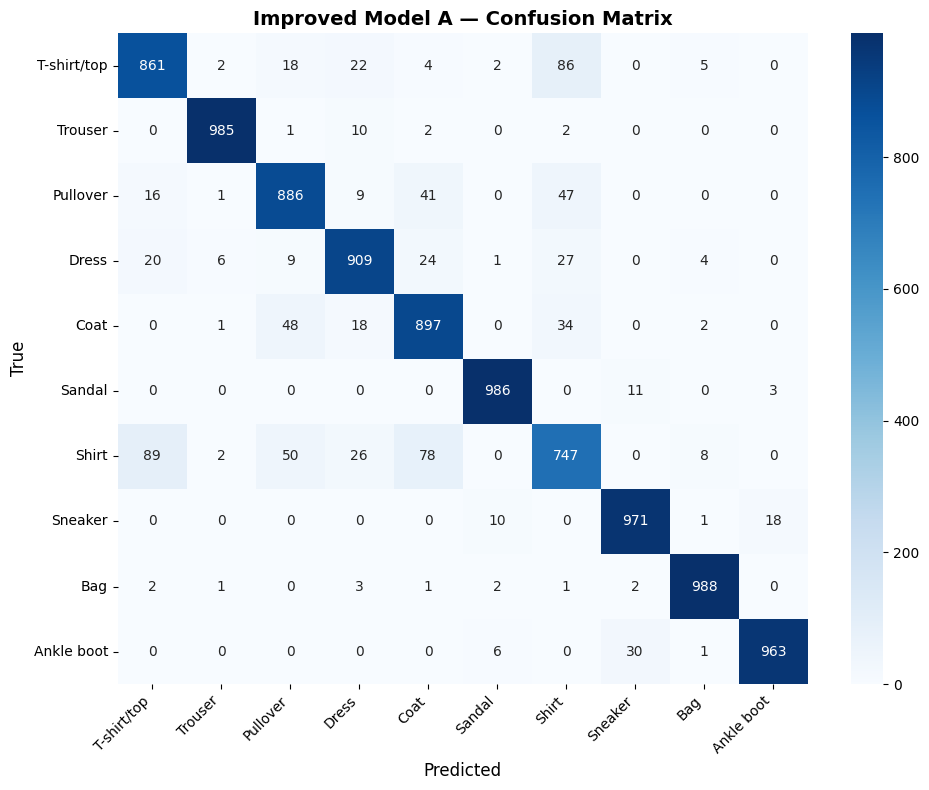

In [31]:
model_a_test_loss, model_a_test_acc, model_a_preds, model_a_labels = full_evaluation(
    model_a, test_loader, loss_fn, device, 'Improved Model A'
)

### 4b. Improved Model B — Advanced Techniques

Model B introduces modern deep learning techniques beyond the reference material to push accuracy further. Each addition is justified below.

| Technique | What it does | Why it helps |
|---|---|---|
| **Batch Normalisation** | Normalises activations within each mini-batch to zero mean and unit variance | Stabilises training by reducing internal covariate shift. Allows higher learning rates and acts as a mild regulariser. |
| **Dropout (0.25 after conv, 0.5 after FC)** | Randomly zeroes activations during training | Prevents co-adaptation of neurons, forcing the network to learn redundant representations. This is the most widely used regularisation technique for neural networks. |
| **Two conv layers per block** | Doubles the depth of feature extraction within each spatial resolution | Two stacked 3x3 convolutions have the same receptive field as a single 5x5 but with more non-linearities and fewer parameters (VGGNet insight). |
| **Adam optimiser** | Maintains per-parameter adaptive learning rates using first and second moment estimates | Converges faster than SGD, especially for sparse gradients. Less sensitive to initial learning rate choice. |
| **Learning rate scheduling (`ReduceLROnPlateau`)** | Reduces learning rate when validation loss stops improving | Allows aggressive early learning followed by fine-grained optimisation in later epochs. Prevents oscillation around the loss minimum. |
| **Data augmentation** (horizontal flip, rotation, translation) | Applies random transformations to training images | Increases effective training set size, reduces overfitting, and improves generalisation to real-world variations in product images. |
| **Kaiming He initialisation** | Initialises weights accounting for ReLU non-linearity | Prevents vanishing/exploding gradients at initialisation, enabling stable training of deeper networks. |


In [34]:
class ImprovedCNN_B(nn.Module):
    """Advanced CNN: BatchNorm, Dropout, double conv blocks, He init."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 1x28x28 -> 32x14x14
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2: 32x14x14 -> 64x7x7
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model_b = ImprovedCNN_B()
print(model_b)
print(f'\nTotal parameters: {sum(p.numel() for p in model_b.parameters()):,}')

ImprovedCNN_B(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilati

In [ ]:
model_b = ImprovedCNN_B().to(device)
optimizer_b = optim.Adam(model_b.parameters(), lr=0.001)
scheduler_b = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b, mode='min', factor=0.5, patience=3
)
history_b = train_model(
    model_b, train_loader_augmented, val_loader,
    optimizer_b, loss_fn, device, num_epochs=20,
    scheduler=scheduler_b, model_name='Improved CNN B'
)

  Epoch  1/75 | Train Loss: 0.9388  Acc: 0.6578 | Val Loss: 0.5197  Acc: 0.7859
  Epoch  2/75 | Train Loss: 0.6707  Acc: 0.7430 | Val Loss: 0.4572  Acc: 0.8284
  Epoch  3/75 | Train Loss: 0.6035  Acc: 0.7685 | Val Loss: 0.3896  Acc: 0.8477
  Epoch  4/75 | Train Loss: 0.5519  Acc: 0.7927 | Val Loss: 0.3706  Acc: 0.8647
  Epoch  5/75 | Train Loss: 0.5188  Acc: 0.8079 | Val Loss: 0.3445  Acc: 0.8734
  Epoch  6/75 | Train Loss: 0.4827  Acc: 0.8237 | Val Loss: 0.3296  Acc: 0.8770
  Epoch  7/75 | Train Loss: 0.4572  Acc: 0.8325 | Val Loss: 0.3126  Acc: 0.8863
  Epoch  8/75 | Train Loss: 0.4414  Acc: 0.8401 | Val Loss: 0.3057  Acc: 0.8889
  Epoch  9/75 | Train Loss: 0.4268  Acc: 0.8457 | Val Loss: 0.2891  Acc: 0.8943
  Epoch 10/75 | Train Loss: 0.4095  Acc: 0.8522 | Val Loss: 0.2754  Acc: 0.8991
  Epoch 11/75 | Train Loss: 0.3971  Acc: 0.8568 | Val Loss: 0.2733  Acc: 0.8992
  Epoch 12/75 | Train Loss: 0.3905  Acc: 0.8605 | Val Loss: 0.2709  Acc: 0.9003
  Epoch 13/75 | Train Loss: 0.3746  Acc:

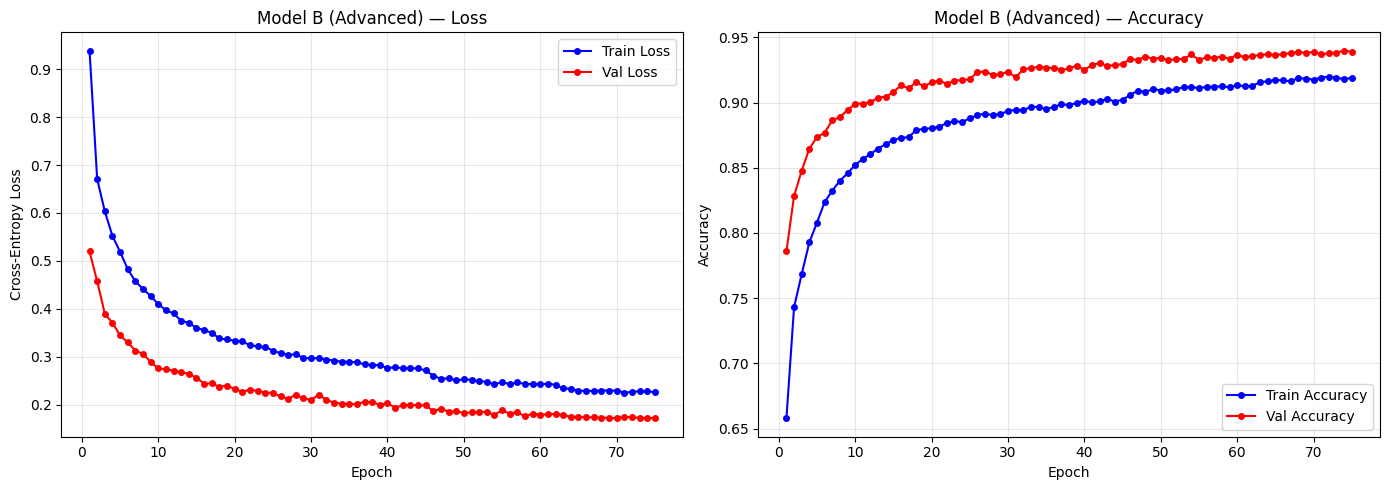

In [41]:
plot_training_curves(history_b, 'Model B (Advanced)')


=== Improved Model B — Test Set Results ===
Test Loss:     0.1828
Test Accuracy: 0.9348 (93.5%)

              precision    recall  f1-score   support

 T-shirt/top     0.8825    0.8790    0.8808      1000
     Trouser     0.9960    0.9910    0.9935      1000
    Pullover     0.9115    0.9170    0.9143      1000
       Dress     0.9373    0.9410    0.9391      1000
        Coat     0.8785    0.9330    0.9049      1000
      Sandal     0.9889    0.9830    0.9860      1000
       Shirt     0.8217    0.7650    0.7923      1000
     Sneaker     0.9616    0.9770    0.9692      1000
         Bag     0.9871    0.9940    0.9905      1000
  Ankle boot     0.9788    0.9680    0.9734      1000

    accuracy                         0.9348     10000
   macro avg     0.9344    0.9348    0.9344     10000
weighted avg     0.9344    0.9348    0.9344     10000



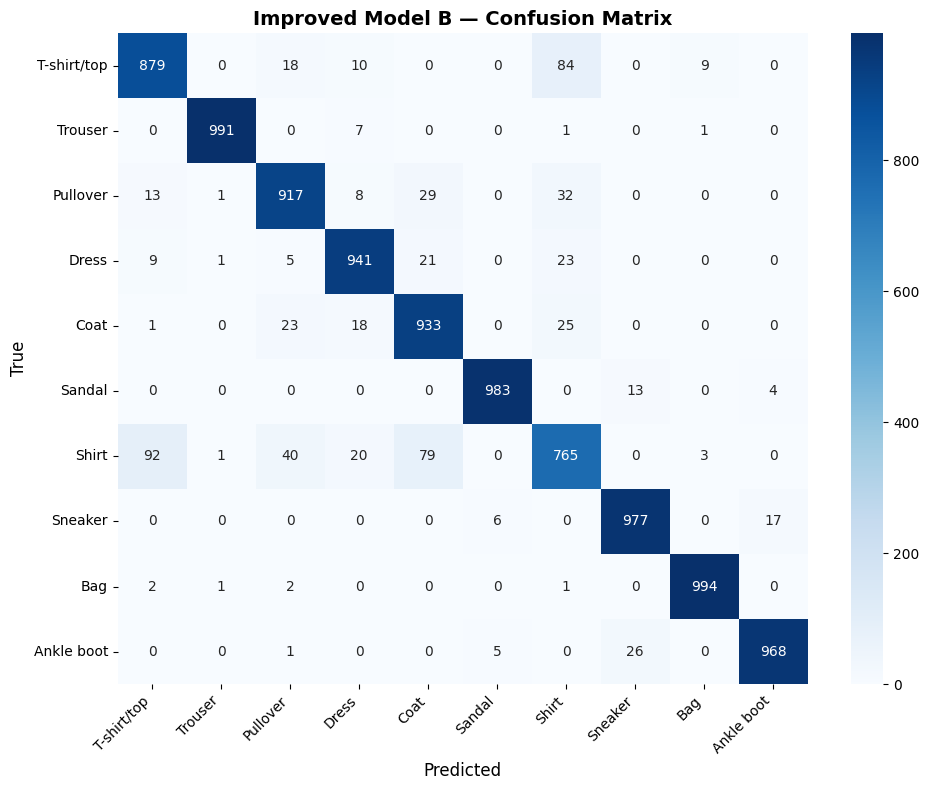

In [42]:
model_b_test_loss, model_b_test_acc, model_b_preds, model_b_labels = full_evaluation(
    model_b, test_loader, loss_fn, device, 'Improved Model B'
)

---
## 5. Evaluation & Error Analysis

We now compare all three models side-by-side and analyse where the best model still struggles.

In [43]:
results = {
    'Baseline CNN': {
        'test_acc': baseline_test_acc, 'test_loss': baseline_test_loss,
        'macro_f1': f1_score(baseline_labels, baseline_preds, average='macro'),
        'params': sum(p.numel() for p in baseline_model.parameters()),
        'train_time': baseline_history['training_time'], 'epochs': 10,
    },
    'Model A (Ref.)': {
        'test_acc': model_a_test_acc, 'test_loss': model_a_test_loss,
        'macro_f1': f1_score(model_a_labels, model_a_preds, average='macro'),
        'params': sum(p.numel() for p in model_a.parameters()),
        'train_time': history_a['training_time'], 'epochs': 20,
    },
    'Model B (Adv.)': {
        'test_acc': model_b_test_acc, 'test_loss': model_b_test_loss,
        'macro_f1': f1_score(model_b_labels, model_b_preds, average='macro'),
        'params': sum(p.numel() for p in model_b.parameters()),
        'train_time': history_b['training_time'], 'epochs': 25,
    }
}

print(f"{'Model':<20} {'Accuracy':>10} {'Macro F1':>10} {'Loss':>10} {'Params':>12} {'Time (s)':>10} {'Epochs':>8}")
print('-' * 82)
for name, r in results.items():
    print(f"{name:<20} {r['test_acc']:>10.4f} {r['macro_f1']:>10.4f} "
          f"{r['test_loss']:>10.4f} {r['params']:>12,} {r['train_time']:>10.1f} {r['epochs']:>8}")

Model                  Accuracy   Macro F1       Loss       Params   Time (s)   Epochs
----------------------------------------------------------------------------------
Baseline CNN             0.8612     0.8631     0.3884       21,840      108.0       10
Model A (Ref.)           0.9193     0.9189     0.6585      390,410      580.6       20
Model B (Adv.)           0.9348     0.9344     0.1828      871,018     1638.6       25


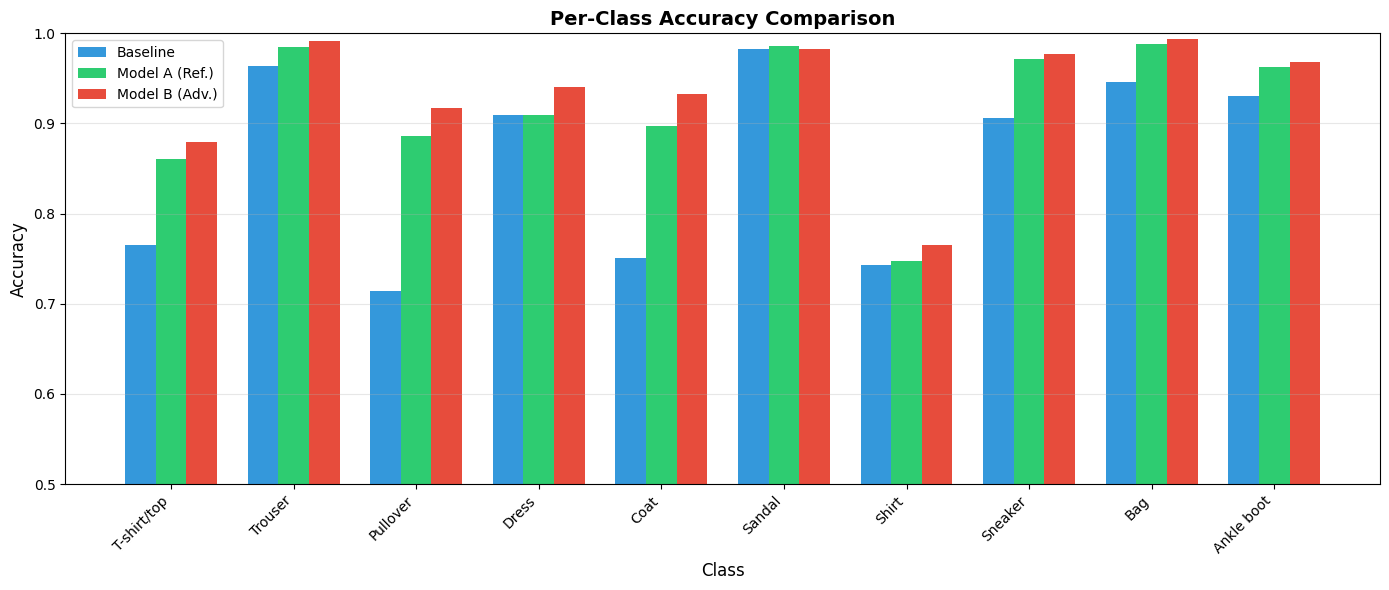

In [44]:
def per_class_accuracy(labels, preds, nc):
    return [(preds[labels == c] == c).mean() for c in range(nc)]

baseline_pc = per_class_accuracy(baseline_labels, baseline_preds, NUM_CLASSES)
model_a_pc  = per_class_accuracy(model_a_labels, model_a_preds, NUM_CLASSES)
model_b_pc  = per_class_accuracy(model_b_labels, model_b_preds, NUM_CLASSES)

x = np.arange(NUM_CLASSES)
width = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, baseline_pc, width, label='Baseline', color='#3498db')
ax.bar(x, model_a_pc, width, label='Model A (Ref.)', color='#2ecc71')
ax.bar(x + width, model_b_pc, width, label='Model B (Adv.)', color='#e74c3c')
ax.set_xlabel('Class', fontsize=12); ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend(); ax.set_ylim(0.5, 1.0); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

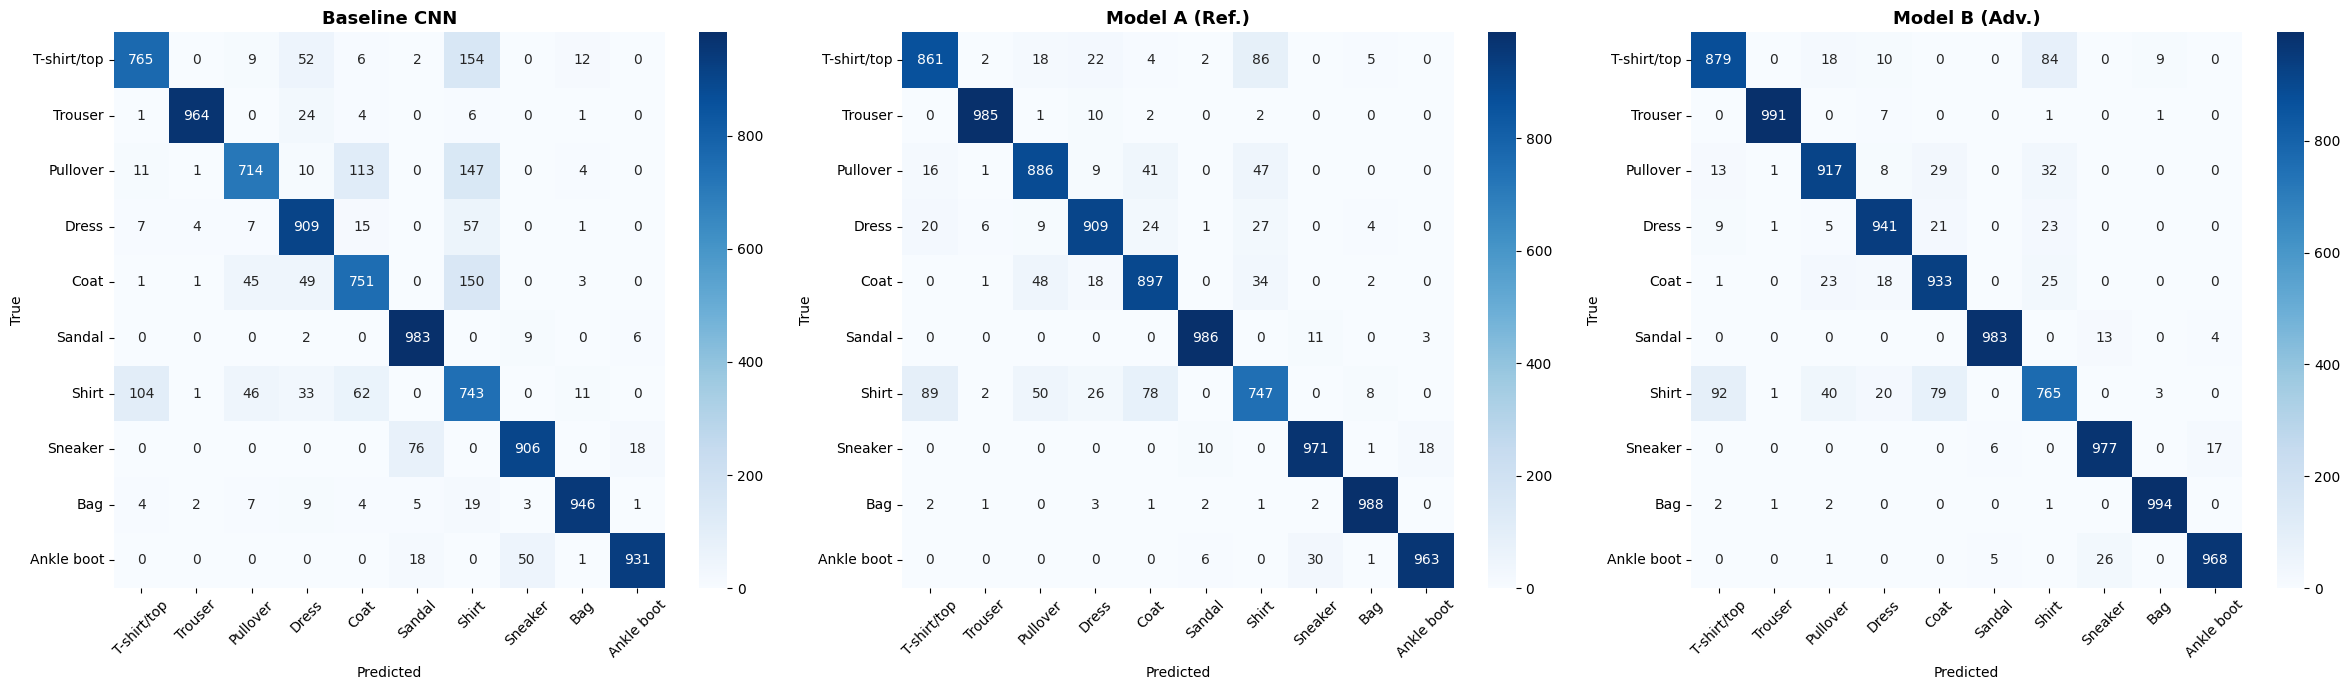

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (name, p, l) in zip(axes, [
    ('Baseline CNN', baseline_preds, baseline_labels),
    ('Model A (Ref.)', model_a_preds, model_a_labels),
    ('Model B (Adv.)', model_b_preds, model_b_labels),
]):
    cm = confusion_matrix(l, p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.show()

In [46]:
# Identify most confused class pairs (Model B)
cm_b = confusion_matrix(model_b_labels, model_b_preds)
cm_off_diag = cm_b.copy()
np.fill_diagonal(cm_off_diag, 0)

print('=== Top 5 Most Confused Class Pairs (Model B) ===')
print(f"{'True Class':<15} {'Predicted As':<15} {'Count':>6}")
print('-' * 40)
confused_pairs = []
for _ in range(5):
    idx = np.unravel_index(cm_off_diag.argmax(), cm_off_diag.shape)
    true_cls, pred_cls = idx
    count = cm_off_diag[true_cls, pred_cls]
    confused_pairs.append((true_cls, pred_cls, count))
    print(f'{CLASS_NAMES[true_cls]:<15} {CLASS_NAMES[pred_cls]:<15} {count:>6}')
    cm_off_diag[true_cls, pred_cls] = 0

=== Top 5 Most Confused Class Pairs (Model B) ===
True Class      Predicted As     Count
----------------------------------------
Shirt           T-shirt/top         92
T-shirt/top     Shirt               84
Shirt           Coat                79
Shirt           Pullover            40
Pullover        Shirt               32



=== Misclassification Examples (Model B) ===


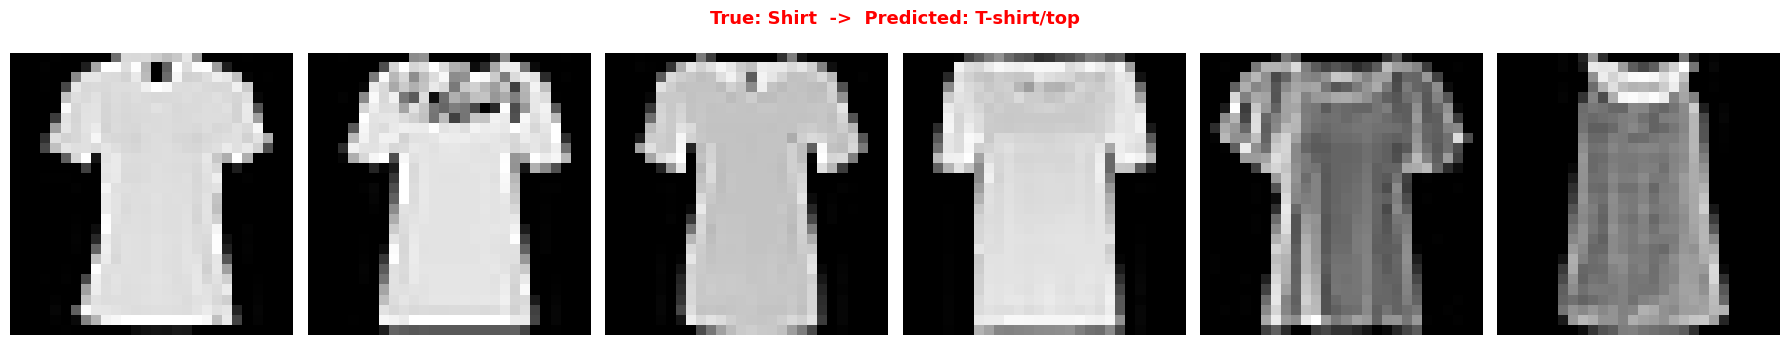

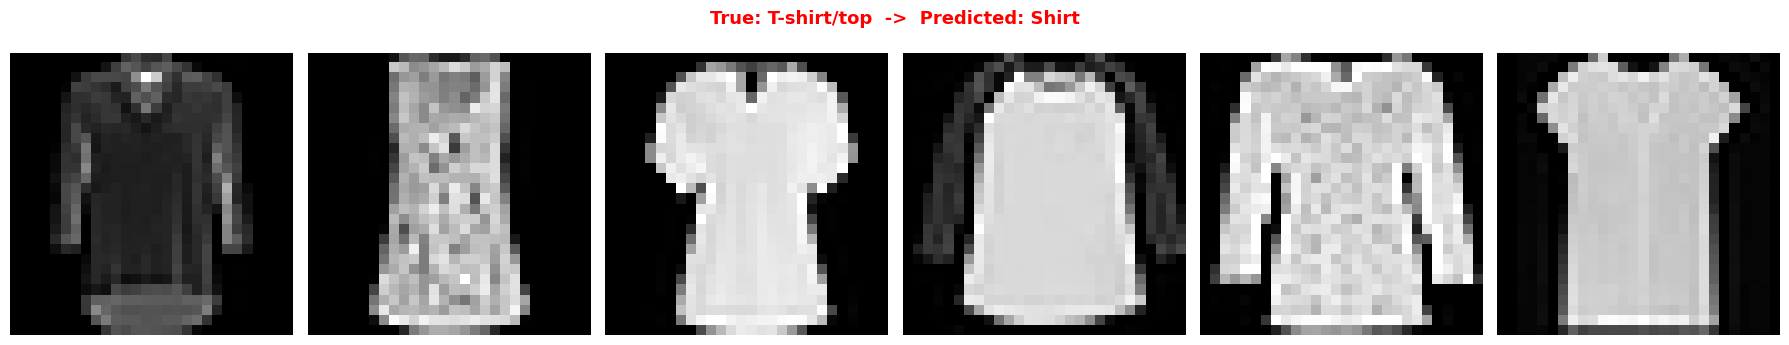

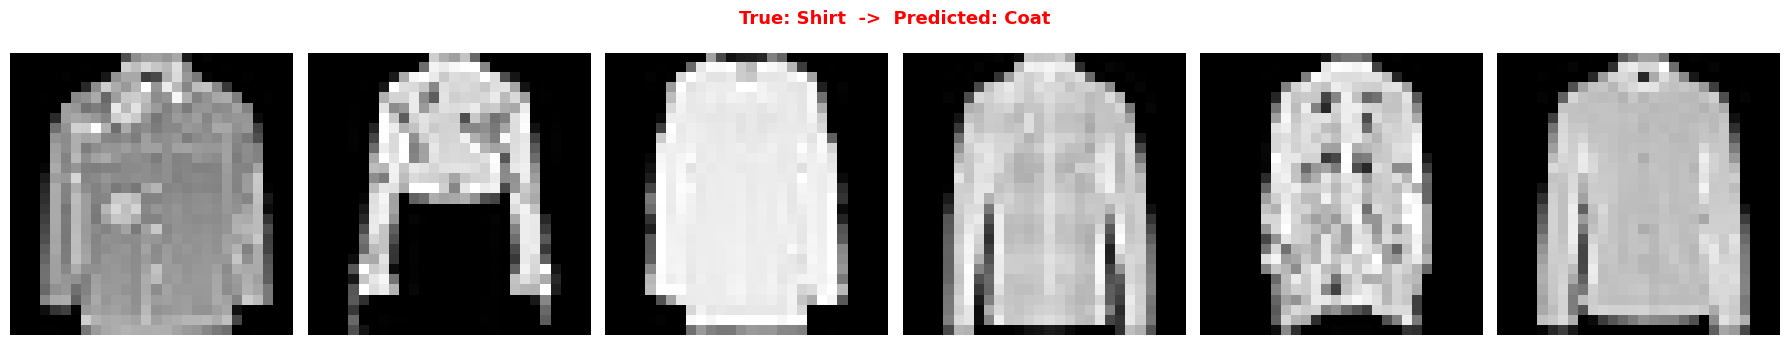

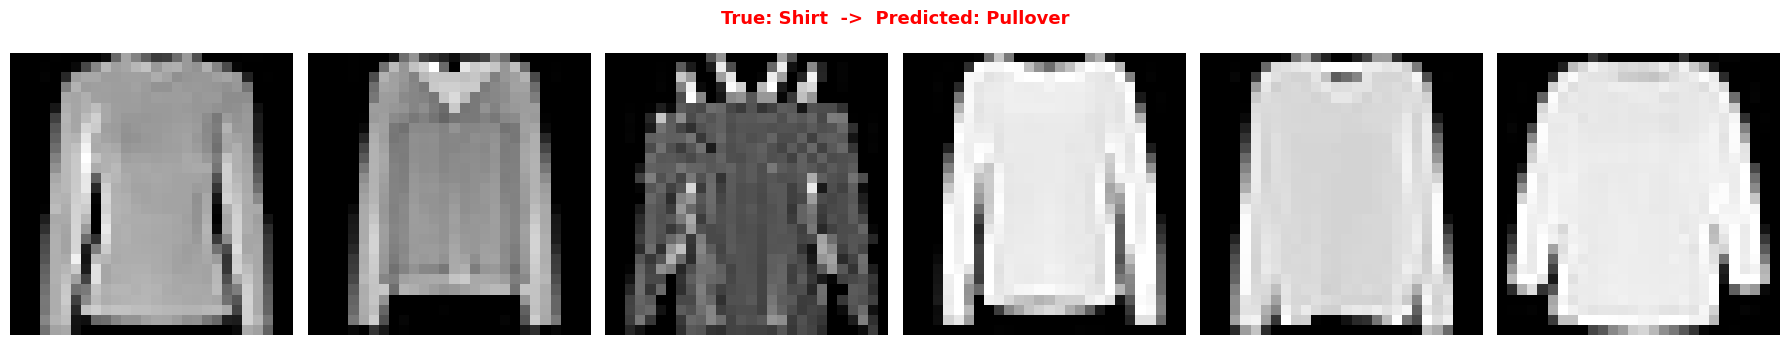

In [47]:
def show_misclassifications(test_ds, preds, labels, true_cls, pred_cls, n=6):
    mask = (labels == true_cls) & (preds == pred_cls)
    mis_idx = np.where(mask)[0]
    if len(mis_idx) == 0:
        print(f'  No misclassifications of {CLASS_NAMES[true_cls]} as {CLASS_NAMES[pred_cls]}.')
        return
    n = min(n, len(mis_idx))
    selected = np.random.choice(mis_idx, size=n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
    fig.suptitle(f'True: {CLASS_NAMES[true_cls]}  ->  Predicted: {CLASS_NAMES[pred_cls]}',
                 fontsize=13, fontweight='bold', color='red')
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, selected):
        img, _ = test_ds[idx]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.axis('off')
    plt.tight_layout(); plt.show()

print('\n=== Misclassification Examples (Model B) ===')
for tc, pc, cnt in confused_pairs[:4]:
    show_misclassifications(test_dataset, model_b_preds, model_b_labels, tc, pc)

### Error Analysis Discussion

The confusion analysis reveals a clear pattern in the model's errors:

**Upper-body garment confusion cluster:**
- **Shirt <-> T-shirt/top**: These items share nearly identical silhouettes at 28x28 resolution. The distinguishing features (collar style, button placket, fabric texture) are too fine-grained to be reliably captured.
- **Shirt <-> Pullover / Coat**: Similar T-shaped outlines make these hard to distinguish, especially when sleeve length is ambiguous at low resolution.

**Footwear confusion cluster:**
- **Sneaker <-> Ankle boot**: Both are enclosed shoes with similar overall shape. The distinguishing features (boot height, sole style) are subtle in small greyscale images.
- **Sandal** is more distinctive (open design) and is rarely confused.

**Easy classes:**
- **Trouser** and **Bag** have highly distinctive shapes and achieve near-perfect accuracy across all three models.

**Root cause:** The 28x28 greyscale resolution fundamentally limits the model's ability to distinguish visually similar classes. Real-world deployment with higher-resolution colour images would significantly reduce these confusions.


---
## 6. Interpretability — Grad-CAM

**Gradient-weighted Class Activation Mapping (Grad-CAM)** helps us understand *what the model is looking at* when it makes a prediction.

**How it works:**
1. Perform a forward pass and record the feature maps from the last convolutional layer.
2. Perform a backward pass from the target class score.
3. Global-average-pool the gradients to get per-channel importance weights.
4. Compute a weighted combination of the feature maps, apply ReLU, and upsample to the input resolution.

The resulting heatmap highlights the spatial regions most important for the model's prediction.

We apply Grad-CAM to **Model B** (the best-performing model) for both correct and incorrect predictions.

In [48]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping."""
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.clone().detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].clone().detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        inp = input_tensor.unsqueeze(0) if input_tensor.dim() == 3 else input_tensor
        inp = inp.to(next(self.model.parameters()).device)
        inp.requires_grad_(True)
        output = self.model(inp)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, target_class].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(28, 28), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, target_class, output.softmax(dim=1)[0, target_class].item()

# Target the post-ReLU activation after the final Conv2d
for m in model_b.modules():
    if isinstance(m, torch.nn.ReLU):
        m.inplace = False
target_layer = model_b.features[13]
grad_cam = GradCAM(model_b, target_layer)
print(f'Grad-CAM target layer: {target_layer}')

Grad-CAM target layer: ReLU()


In [49]:
def show_gradcam_grid(test_ds, indices, gc, title, ncols=5):
    n = len(indices)
    nrows = max(1, (n + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols * 2, figsize=(ncols * 5, nrows * 3))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    if nrows == 1:
        axes = axes.reshape(1, -1)
    for i, idx in enumerate(indices):
        row = i // ncols
        col = i % ncols
        img_tensor, true_label = test_ds[idx]
        cam, pred_class, confidence = gc.generate(img_tensor)
        img_display = img_tensor.squeeze().numpy() * FMNIST_STD[0] + FMNIST_MEAN[0]
        img_display = np.clip(img_display, 0, 1)
        ax_orig = axes[row, col * 2]
        ax_orig.imshow(img_display, cmap='gray')
        colour = 'green' if pred_class == true_label else 'red'
        ax_orig.set_title(f'True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_class]} ({confidence:.0%})',
                          fontsize=8, color=colour)
        ax_orig.axis('off')
        ax_cam = axes[row, col * 2 + 1]
        ax_cam.imshow(img_display, cmap='gray')
        ax_cam.imshow(cam, cmap='jet', alpha=0.5)
        ax_cam.set_title('Grad-CAM', fontsize=8)
        ax_cam.axis('off')
    for i in range(n, nrows * ncols):
        row = i // ncols
        col = i % ncols
        axes[row, col * 2].axis('off')
        axes[row, col * 2 + 1].axis('off')
    plt.tight_layout(); plt.show()

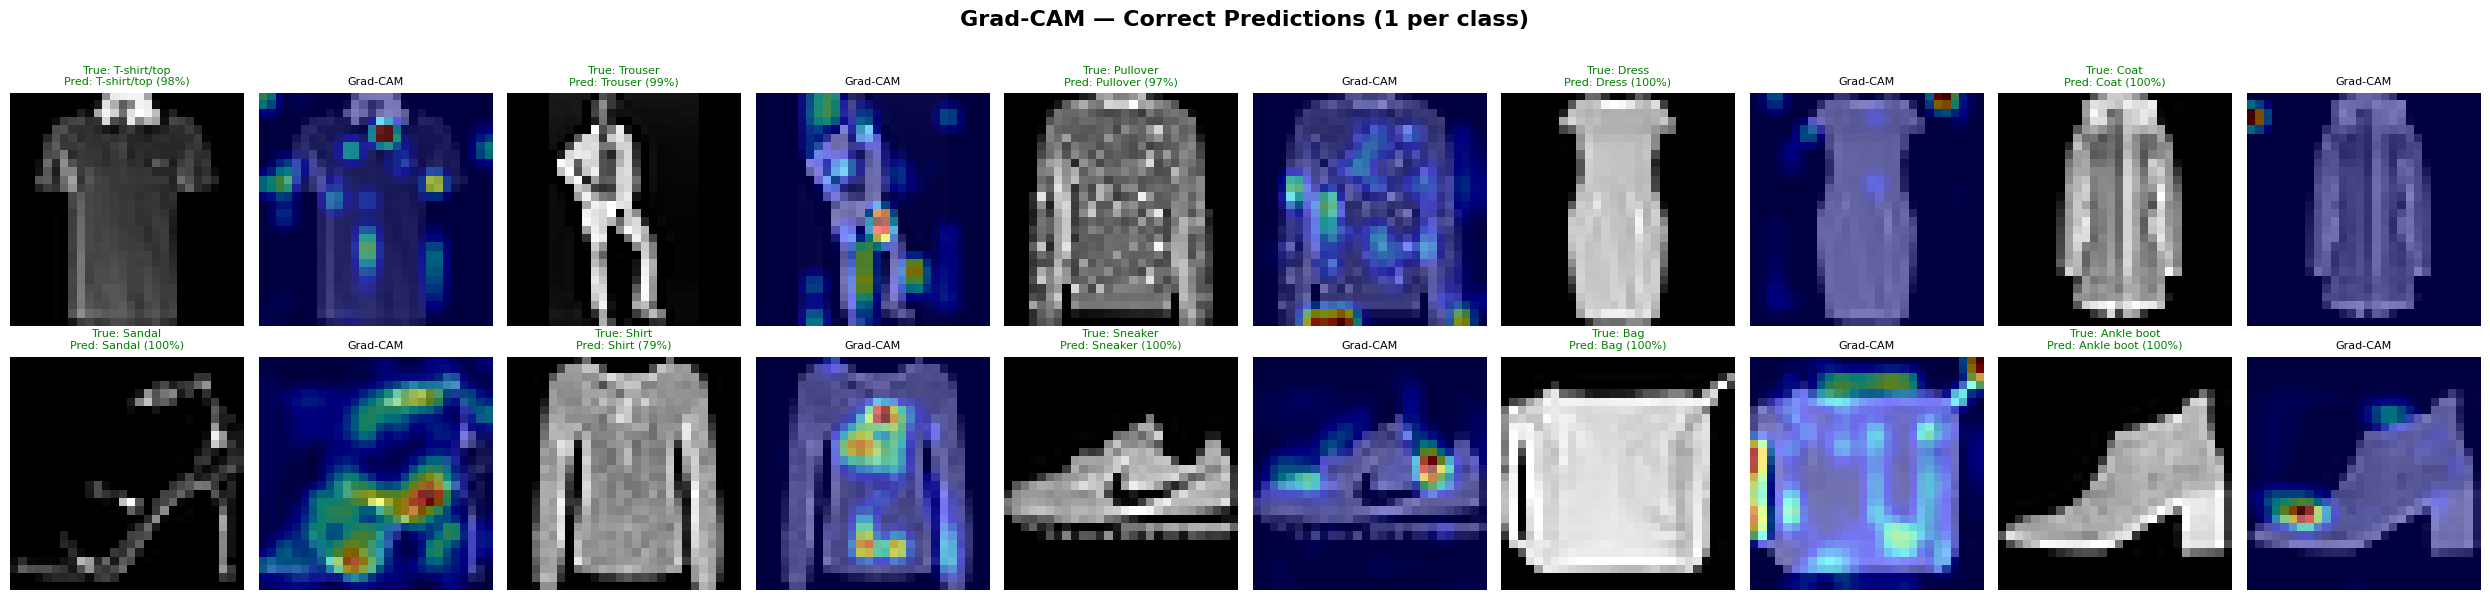

In [50]:
# Grad-CAM for CORRECT predictions (1 per class)
correct_indices = []
for cls in range(NUM_CLASSES):
    mask = (model_b_labels == cls) & (model_b_preds == cls)
    candidates = np.where(mask)[0]
    if len(candidates) >= 1:
        correct_indices.append(np.random.choice(candidates))

show_gradcam_grid(test_dataset, correct_indices, grad_cam,
                  'Grad-CAM — Correct Predictions (1 per class)')

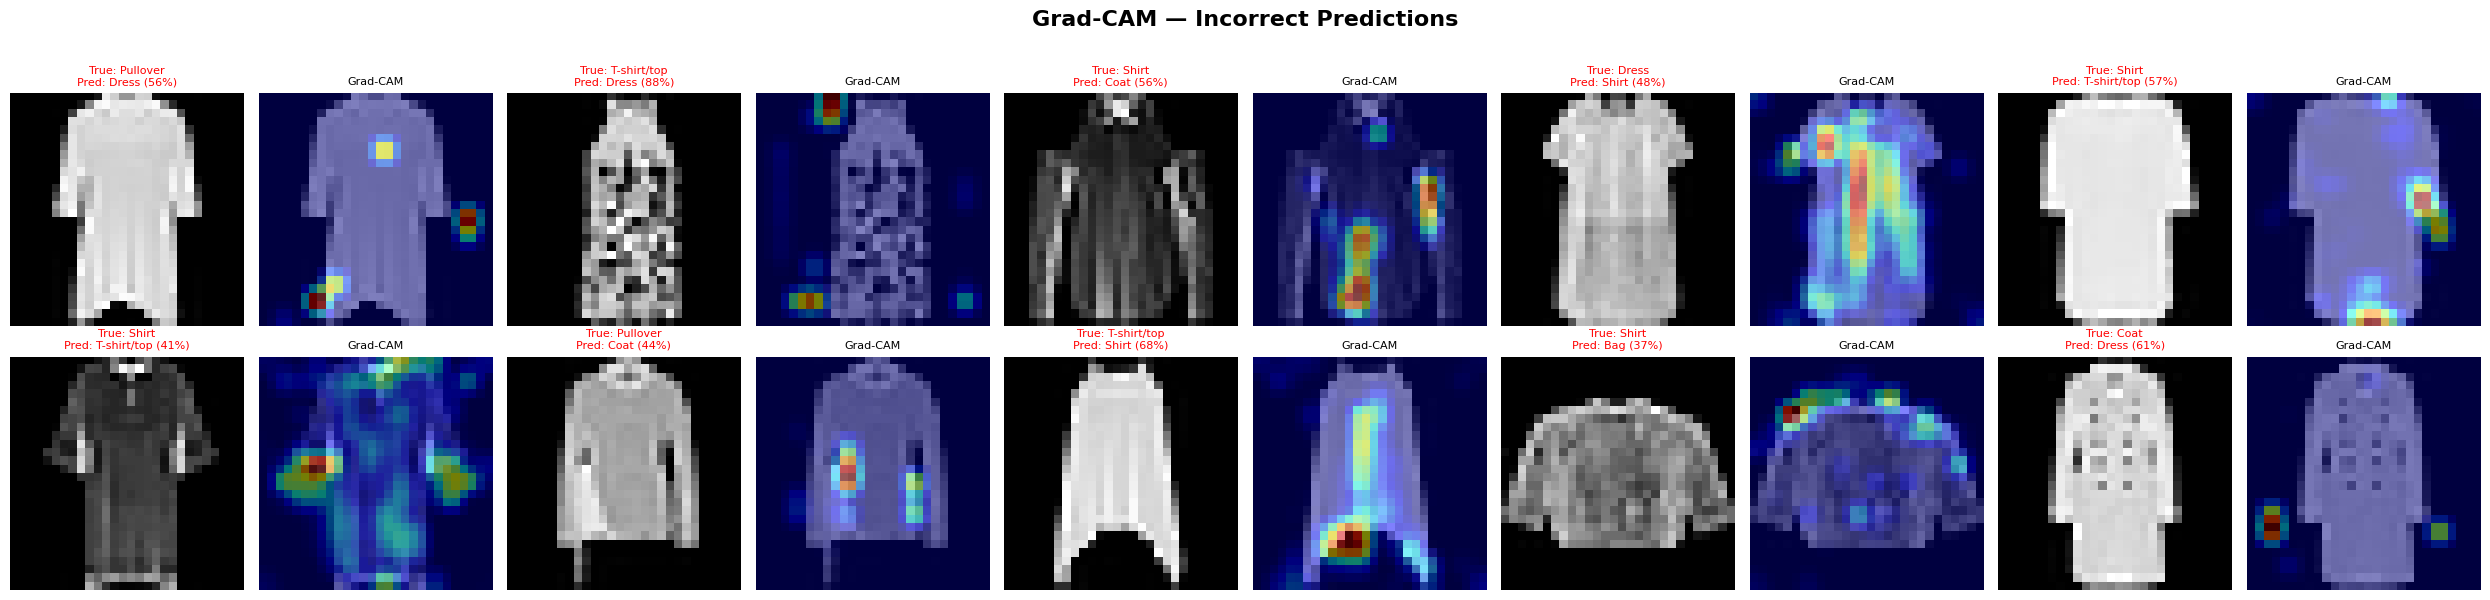

In [53]:
# Grad-CAM for INCORRECT predictions
incorrect_mask = model_b_labels != model_b_preds
incorrect_indices = np.where(incorrect_mask)[0]
selected_incorrect = np.random.choice(incorrect_indices, min(10, len(incorrect_indices)), replace=False)

show_gradcam_grid(test_dataset, selected_incorrect, grad_cam,
                  'Grad-CAM — Incorrect Predictions')